In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

!{sys.executable} -m pip install stemgraphic
df = pd.read_csv('https://raw.githubusercontent.com/kimurasaika/car_price_prediction/refs/heads/main/data2.csv')
df = df.drop(columns=['obs','month','month_num','year','PPI_IDX','GOLD'])

df['M2'] = df['M2'].str.replace(',', '').astype(float)

df.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.6 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=7b8861ba5afe7f4d5dec215ba82f1a3394eb9b12cf7afa70ec0298b15d80136e
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


,CPI_IDX,EX_AVG_USD,EXI_IDX,IMI_IDX,M2,policy,oilwtiprice,unemployment
0,90.16,32.7344,94.8,87.0,16947602.0,2.00,48.24,1.06
1,90.26,32.5734,95.0,87.2,17113914.0,2.00,49.76,0.82
2,90.42,32.6314,95.1,86.7,17193104.0,1.75,47.60,0.99
3,90.43,32.5095,95.2,87.3,17166475.0,1.50,59.63,0.85
4,90.58,33.5519,95.5,88.0,17190904.0,1.50,60.30,0.93


In [ ]:
# sns.pairplot(df, diag_kind='kde')

Text(0.5, 1.0, 'Correlation Heatmap')

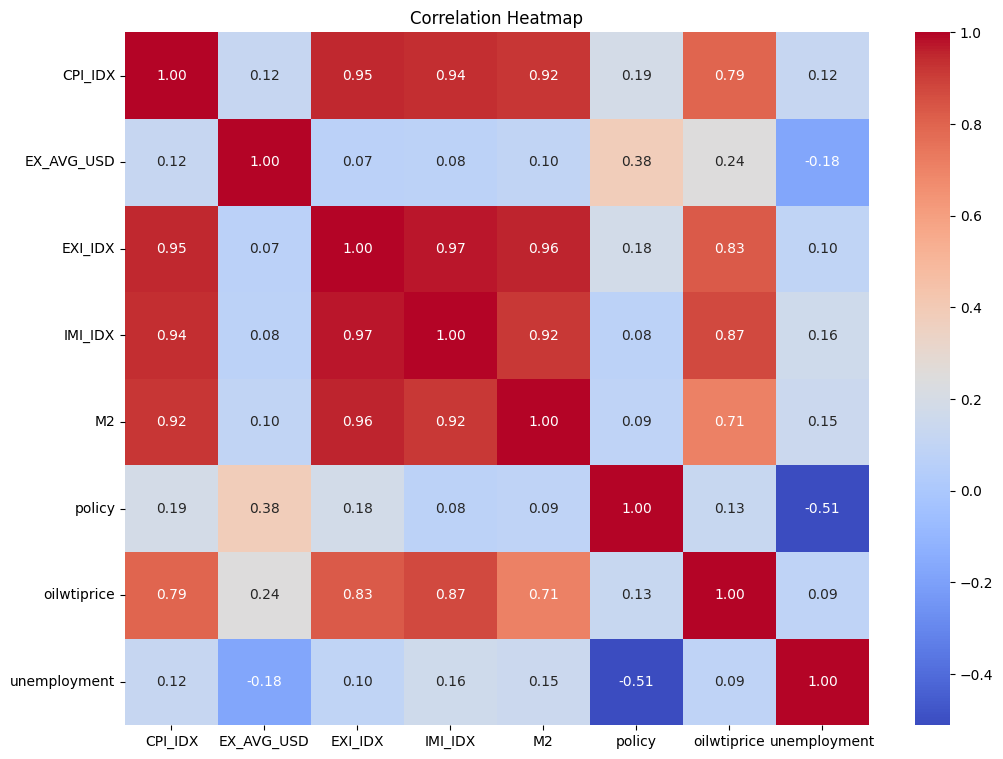

In [ ]:
nu_df = df.select_dtypes(include = [np.number])
plt.figure(figsize = (12,9))
corr = nu_df.corr(method = 'spearman')
sns.heatmap(corr , fmt = '.2f' , annot = True , cmap = 'coolwarm' )
plt.title('Correlation Heatmap')

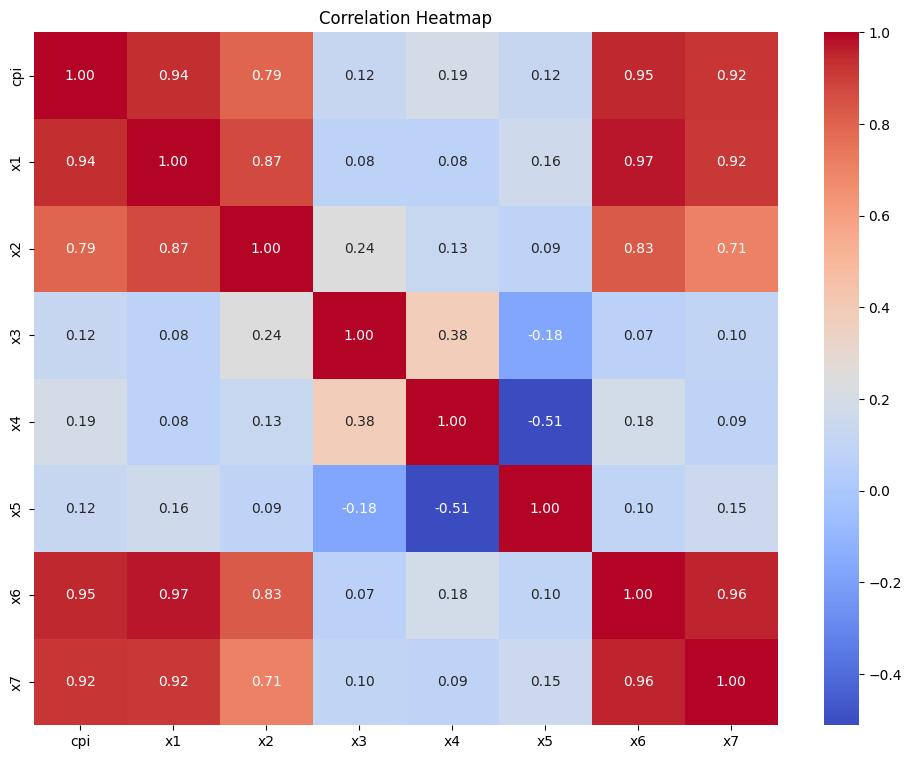

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
nu_df = df.select_dtypes(include=[np.number])

# Rename columns as you did
nu_df.columns = ['cpi', 'x3', 'x6', 'x1', 'x7', 'x4', 'x2', 'x5']

# Reorder the columns to be in the order you want (x1 to x7 + 'CPI' as appropriate)
# If you want to order strictly as x1, x2, x3, ..., x7 and put CPI last or first, define that clearly.

# Example reorder placing CPI last:
cols_ordered = ['cpi','x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7']
nu_df = nu_df[cols_ordered]

# Calculate correlation matrix with Spearman method
corr = nu_df.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(12,9))
sns.heatmap(corr, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



In [ ]:
X = df.drop(columns=['CPI_IDX'])
y = df['CPI_IDX']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1711)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
# @title
# from sklearn.model_selection import train_test_split

# # List of indices that should be in the test set
# required_test_indices = [75, 79, 80, 97, 98]

# # Function to check if all required indices are in the test set
# def check_test_indices(test_indices, required_indices):
#     return all(index in test_indices for index in required_indices)

# # Iterate through different random states
# found_random_state = None
# for random_state in range(1000000): # You can adjust the range
#     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
#         X, y, test_size=0.1, random_state=random_state
#     )

#     # Get the original indices of the test set
#     test_indices = X_test_temp.index.tolist()

#     # Check if all required indices are in the test set
#     if check_test_indices(test_indices, required_test_indices):
#         found_random_state = random_state
#         print(f"Found random_state: {found_random_state}")
#         break

# if found_random_state is None:
#     print("Could not find a random_state that satisfies the condition in the given range.")

In [ ]:
# X_test['IMI_IDX'] = np.log1p(X_test['IMI_IDX'])
# X_train['IMI_IDX'] = np.log1p(X_train['IMI_IDX'])

In [ ]:
# y_train = np.log1p(y_train)
# y_test = np.log1p(y_test)

In [ ]:
print('X_test')
print(X_test.isna().sum())
print('-----------------')
print('X_train')
print(X_train.isna().sum())

X_test
EX_AVG_USD      0
EXI_IDX         0
IMI_IDX         0
M2              0
policy          0
oilwtiprice     0
unemployment    0
dtype: int64
-----------------
X_train
EX_AVG_USD       0
EXI_IDX          0
IMI_IDX          0
M2               0
policy           0
oilwtiprice      0
unemployment    15
dtype: int64


compare imputer

In [ ]:
# @title
# from sklearn.linear_model import BayesianRidge, LinearRegression, Ridge, Lasso, ElasticNet
# from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.neighbors import KNeighborsRegressor

# X_train_loop = X_train.copy()
# X_test_loop = X_test.copy()
# estimators = [
#     BayesianRidge(),
#     DecisionTreeRegressor(random_state=1234),
#     ExtraTreesRegressor(random_state=1234),
#     RandomForestRegressor(random_state=1234),
#     KNeighborsRegressor(),
#     ElasticNet(random_state=1234),
#     LinearRegression(),
#     Ridge(random_state=1234),
#     Lasso(random_state=1234)
# ]

# results = {}

# for estimator in estimators:
#     estimator_name = type(estimator).__name__
#     print(f"Testing with estimator: {estimator_name}")

#     # Create and fit IterativeImputer
#     imputer = IterativeImputer(estimator=estimator, max_iter=10, random_state=1234)
#     imputer.fit(X_train_loop)

#     # Transform data
#     X_train_imputed = pd.DataFrame(imputer.transform(X_train_loop), columns=X_train_loop.columns)
#     X_test_imputed = pd.DataFrame(imputer.transform(X_test_loop), columns=X_test_loop.columns)

#     # Create and fit Linear Regression model
#     linear_model = LinearRegression()
#     linear_model.fit(X_train_imputed, y_train)

#     # Predict
#     y_pred = linear_model.predict(X_test_imputed)

#     # Calculate metrics
#     r2 = r2_score(y_test, y_pred)
#     mse = mean_squared_error(y_test, y_pred)
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mse)

#     # Store results
#     results[estimator_name] = {
#         'R-squared': r2,
#         'MSE': mse,
#         'MAE': mae,
#         'RMSE': rmse
#     }

#     # Print results for the current estimator
#     print(f'  R-squared: {r2:.3f}')
#     print(f'  MSE: {mse:.3f}')
#     print(f'  MAE: {mae:.3f}')
#     print(f'  RMSE: {rmse:.3f}')
#     print("-" * 20)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=1234)
imputer.fit(X_train)
X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)

อันนี้ไว้เปิดปิดสเกล

In [ ]:
# @title
# from sklearn.preprocessing import StandardScaler , RobustScaler
# from sklearn.impute import KNNImputer
# scaler = RobustScaler()
# scaler.fit(X_train)
# X_train_sc = scaler.transform(X_train)
# X_train = pd.DataFrame(X_train_sc, columns=X_train.columns)
# X_test_sc = scaler.transform(X_test)
# X_test = pd.DataFrame(X_test_sc, columns=X_test.columns)


# อันนี้ไม่เกี่ยว
# imputer = KNNImputer(n_neighbors=3, weights='uniform')
# X_trainn = scaler.inverse_transform(X_train_sc)

In [ ]:
# X_train = pd.DataFrame(X_trainn, columns=X_train.columns)
# X_train

In [ ]:
print(X_train.head)
print('-----------')
print(X_train.isna().sum())

<bound method NDFrame.head of      EX_AVG_USD  EXI_IDX  IMI_IDX          M2  policy  oilwtiprice  \
0       35.8541    110.0    110.3  25764696.0    2.50        78.26   
1       36.4299    108.0    111.6  24956718.0    1.25        80.56   
2       33.7497     97.0     87.2  18590428.0    1.50        50.17   
3       35.0500     94.6     85.5  17986304.0    1.50        46.86   
4       35.3053     94.6     84.4  17838170.0    1.50        48.33   
..          ...      ...      ...         ...     ...          ...   
103     35.4176     93.7     85.4  17027719.0    1.50        49.20   
104     31.9729    101.2     93.7  19563179.0    1.50        67.04   
105     30.3675    100.7     92.9  20598791.0    1.25        54.18   
106     30.7695    100.9     93.0  20338459.0    1.50        55.10   
107     30.5737    101.1     93.2  20437342.0    1.50        54.07   

     unemployment  
0            0.98  
1            1.15  
2            1.24  
3            1.19  
4            1.01  
..       

mallow

In [ ]:
# @title
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import statsmodels.api as sm
# import matplotlib.pyplot as plt
# import pylab
# from scipy import stats
# def mallows_cp(X, y, model, sigma2_full):
#     """
#     Calculate Mallows' Cp for a given model.
#     X: DataFrame of predictors (with constant)
#     y: Series or array of dependent variable
#     model: Fitted statsmodels OLS model
#     sigma2_full: Variance estimate from the full model
#     Returns: Cp value
#     """
#     sse = np.sum(model.resid ** 2)  # Sum of squared errors
#     n = len(y)  # Number of observations
#     p = len(model.params)  # Number of parameters (including intercept)
#     return sse / sigma2_full + 2 * p - n

# # Function for backward elimination using Mallows' Cp
# def backward_elimination(X, y):
#     """
#     Perform backward elimination based on Mallows' Cp criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     # Fit the full model to get sigma^2
#     X_full = sm.add_constant(X)
#     full_model = sm.OLS(y, X_full).fit()
#     sigma2_full = np.sum(full_model.resid ** 2) / (len(y) - len(full_model.params))

#     # Initialize with all features
#     selected_features = X.columns.tolist()
#     X_current = sm.add_constant(X[selected_features])

#     while len(selected_features) > 0:
#         # Fit the current model
#         model = sm.OLS(y, X_current).fit()
#         current_cp = mallows_cp(X_current, y, model, sigma2_full)

#         # Try removing each feature and calculate Cp
#         cp_values = []
#         for feature in selected_features:
#             temp_features = [f for f in selected_features if f != feature]
#             X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#             model_temp = sm.OLS(y, X_temp).fit()
#             cp = mallows_cp(X_temp, y, model_temp, sigma2_full)
#             cp_values.append((feature, cp))

#         # Find the model with the lowest Cp
#         if cp_values:
#             worst_feature, min_cp = min(cp_values, key=lambda x: x[1])
#             # Only remove if the reduced model has a lower Cp
#             if min_cp < current_cp:
#                 selected_features.remove(worst_feature)
#                 X_current = sm.add_constant(X[selected_features]) if selected_features else X_current[['const']]
#             else:
#                 break
#         else:
#             break

#     return selected_features

# # Function for stepwise selection using Mallows' Cp
# def stepwise_selection(X, y):
#     """
#     Perform stepwise selection based on Mallows' Cp criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     # Fit the full model to get sigma^2
#     X_full = sm.add_constant(X)
#     full_model = sm.OLS(y, X_full).fit()
#     sigma2_full = np.sum(full_model.resid ** 2) / (len(y) - len(full_model.params))

#     initial_features = X.columns.tolist()
#     selected_features = []

#     while True:
#         # Forward selection: Try adding each remaining feature
#         remaining_features = [f for f in initial_features if f not in selected_features]
#         cp_values = []

#         for feature in remaining_features:
#             temp_features = selected_features + [feature]
#             X_temp = sm.add_constant(X[temp_features])
#             model_temp = sm.OLS(y, X_temp).fit()
#             cp = mallows_cp(X_temp, y, model_temp, sigma2_full)
#             cp_values.append((feature, cp))

#         # Add the feature with the lowest Cp, if it improves the model
#         if cp_values:
#             best_feature, min_cp = min(cp_values, key=lambda x: x[1])
#             # Fit current model to compare
#             current_cp = float('inf') if not selected_features else mallows_cp(sm.add_constant(X[selected_features]), y, sm.OLS(y, sm.add_constant(X[selected_features])).fit(), sigma2_full)
#             if min_cp < current_cp or not selected_features:
#                 selected_features.append(best_feature)
#             else:
#                 break
#         else:
#             break

#         # Backward elimination: Check if removing any feature improves Cp
#         while selected_features:
#             X_current = sm.add_constant(X[selected_features])
#             model_current = sm.OLS(y, X_current).fit()
#             current_cp = mallows_cp(X_current, y, model_current, sigma2_full)

#             cp_values = []
#             for feature in selected_features:
#                 temp_features = [f for f in selected_features if f != feature]
#                 X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#                 model_temp = sm.OLS(y, X_temp).fit()
#                 cp = mallows_cp(X_temp, y, model_temp, sigma2_full)
#                 cp_values.append((feature, cp))

#             if cp_values:
#                 worst_feature, min_cp = min(cp_values, key=lambda x: x[1])
#                 if min_cp < current_cp:
#                     selected_features.remove(worst_feature)
#                 else:
#                     break
#             else:
#                 break

#     return selected_features

p-value

In [ ]:
# @title
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pylab
from scipy import stats

def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.05, verbose=True):

    included = []  # เริ่มจากโมเดลว่าง
    excluded = list(X.columns)  # ตัวแปรทั้งหมดที่ยังไม่ได้เลือก

    while True:
        changed = False

        # Forward Selection: ลองเพิ่มตัวแปรที่เหลือทีละตัว
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_feature in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_feature]])).fit()
            new_pval[new_feature] = model.pvalues[new_feature]

        best_pval = new_pval.min()
        if best_pval < threshold_in:  # ถ้ามีตัวแปรที่ p-value < threshold_in
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            excluded.remove(best_feature)
            changed = True
            if verbose:
                print(f'Add {best_feature} with p-value {best_pval:.6f}')

        # Backward Elimination: ตรวจสอบตัวแปรที่อยู่ในโมเดล
        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]  # Exclude constant
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:  # ถ้ามีตัวแปรที่ p-value > threshold_out
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                excluded.append(worst_feature)
                changed = True
                if verbose:
                    print(f'Remove {worst_feature} with p-value {worst_pval:.6f}')

        # ถ้าไม่มีอะไรเปลี่ยนแปลง (ไม่เพิ่มหรือลบตัวแปร) ออกจาก loop
        if not changed:
            break

    return included
def backward_elimination(X, y, threshold_out=0.05, verbose=True):
    included = list(X.columns)
    while included:
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        pvalues = model.pvalues.iloc[1:]  # Exclude constant
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f'Remove {worst_feature} with p-value {worst_pval:.6f}')
        else:
            break
    return included


def calculate_vif(df, vif_threshold=7):
    df_with_const = sm.add_constant(df)
    vif_df = pd.DataFrame()
    vif_df['Column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df_with_const.values, i + 1) for i in range(df.shape[1])]

    selected_features = vif_df[vif_df['VIF'] < vif_threshold]['Column'].tolist()

    if 'const' in selected_features:
        selected_features.remove('const')

    return vif_df

R-sq adj

In [ ]:
# @title
# # @title
# import pandas as pd
# import numpy as np
# import statsmodels.api as sm

# # Function for backward elimination using Adjusted R²
# def backward_elimination(X, y):
#     """
#     Perform backward elimination based on Adjusted R² criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     # Initialize with all features
#     selected_features = X.columns.tolist()
#     X_current = sm.add_constant(X[selected_features])

#     while len(selected_features) > 0:
#         # Fit the current model
#         model = sm.OLS(y, X_current).fit()
#         current_adj_r2 = model.rsquared_adj

#         # Try removing each feature and calculate Adjusted R²
#         adj_r2_values = []
#         for feature in selected_features:
#             temp_features = [f for f in selected_features if f != feature]
#             X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#             model_temp = sm.OLS(y, X_temp).fit()
#             adj_r2_values.append((feature, model_temp.rsquared_adj))

#         # Find the model with the highest Adjusted R²
#         if adj_r2_values:
#             worst_feature, max_adj_r2 = max(adj_r2_values, key=lambda x: x[1])
#             # Only remove if the reduced model has a higher Adjusted R²
#             if max_adj_r2 > current_adj_r2:
#                 selected_features.remove(worst_feature)
#                 X_current = sm.add_constant(X[selected_features]) if selected_features else X_current[['const']]
#             else:
#                 break
#         else:
#             break

#     return selected_features

# # Function for stepwise selection using Adjusted R²
# def stepwise_selection(X, y):
#     """
#     Perform stepwise selection based on Adjusted R² criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     initial_features = X.columns.tolist()
#     selected_features = []

#     while True:
#         # Forward selection: Try adding each remaining feature
#         remaining_features = [f for f in initial_features if f not in selected_features]
#         adj_r2_values = []

#         for feature in remaining_features:
#             temp_features = selected_features + [feature]
#             X_temp = sm.add_constant(X[temp_features])
#             model_temp = sm.OLS(y, X_temp).fit()
#             adj_r2_values.append((feature, model_temp.rsquared_adj))

#         # Add the feature with the highest Adjusted R², if it improves the model
#         if adj_r2_values:
#             best_feature, max_adj_r2 = max(adj_r2_values, key=lambda x: x[1])
#             # Fit current model to compare
#             current_adj_r2 = -float('inf') if not selected_features else sm.OLS(y, sm.add_constant(X[selected_features])).fit().rsquared_adj
#             if max_adj_r2 > current_adj_r2:
#                 selected_features.append(best_feature)
#             else:
#                 break
#         else:
#             break

#         # Backward elimination: Check if removing any feature improves Adjusted R²
#         while selected_features:
#             X_current = sm.add_constant(X[selected_features])
#             model_current = sm.OLS(y, X_current).fit()
#             current_adj_r2 = model_current.rsquared_adj

#             adj_r2_values = []
#             for feature in selected_features:
#                 temp_features = [f for f in selected_features if f != feature]
#                 X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#                 model_temp = sm.OLS(y, X_temp).fit()
#                 adj_r2_values.append((feature, model_temp.rsquared_adj))

#             if adj_r2_values:
#                 worst_feature, max_adj_r2 = max(adj_r2_values, key=lambda x: x[1])
#                 if max_adj_r2 > current_adj_r2:
#                     selected_features.remove(worst_feature)
#                 else:
#                     break
#             else:
#                 break

#     return selected_features

R-sq

In [ ]:
# @title
# import pandas as pd
# import numpy as np
# import statsmodels.api as sm

# # Function for backward elimination using R²
# def backward_elimination(X, y):
#     """
#     Perform backward elimination based on R² criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     # Initialize with all features
#     selected_features = X.columns.tolist()
#     X_current = sm.add_constant(X[selected_features])

#     while len(selected_features) > 0:
#         # Fit the current model
#         model = sm.OLS(y, X_current).fit()
#         current_r2 = model.rsquared

#         # Try removing each feature and calculate R²
#         r2_values = []
#         for feature in selected_features:
#             temp_features = [f for f in selected_features if f != feature]
#             X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#             model_temp = sm.OLS(y, X_temp).fit()
#             r2_values.append((feature, model_temp.rsquared))

#         # Find the model with the highest R²
#         if r2_values:
#             worst_feature, max_r2 = max(r2_values, key=lambda x: x[1])
#             # Only remove if the reduced model has a higher or equal R² (or minimal loss)
#             # Use a small tolerance to allow minor R² reductions
#             if max_r2 >= current_r2 - 0.01:  # Tolerance of 0.01 to avoid overly complex models
#                 selected_features.remove(worst_feature)
#                 X_current = sm.add_constant(X[selected_features]) if selected_features else X_current[['const']]
#             else:
#                 break
#         else:
#             break

#     return selected_features

# # Function for stepwise selection using R²
# def stepwise_selection(X, y):
#     """
#     Perform stepwise selection based on R² criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     initial_features = X.columns.tolist()
#     selected_features = []

#     while True:
#         # Forward selection: Try adding each remaining feature
#         remaining_features = [f for f in initial_features if f not in selected_features]
#         r2_values = []

#         for feature in remaining_features:
#             temp_features = selected_features + [feature]
#             X_temp = sm.add_constant(X[temp_features])
#             model_temp = sm.OLS(y, X_temp).fit()
#             r2_values.append((feature, model_temp.rsquared))

#         # Add the feature with the highest R², if it improves the model
#         if r2_values:
#             best_feature, max_r2 = max(r2_values, key=lambda x: x[1])
#             # Fit current model to compare
#             current_r2 = -float('inf') if not selected_features else sm.OLS(y, sm.add_constant(X[selected_features])).fit().rsquared
#             if max_r2 > current_r2:
#                 selected_features.append(best_feature)
#             else:
#                 break
#         else:
#             break

#         # Backward elimination: Check if removing any feature maintains or improves R²
#         while selected_features:
#             X_current = sm.add_constant(X[selected_features])
#             model_current = sm.OLS(y, X_current).fit()
#             current_r2 = model_current.rsquared

#             r2_values = []
#             for feature in selected_features:
#                 temp_features = [f for f in selected_features if f != feature]
#                 X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#                 model_temp = sm.OLS(y, X_temp).fit()
#                 r2_values.append((feature, model_temp.rsquared))

#             if r2_values:
#                 worst_feature, max_r2 = max(r2_values, key=lambda x: x[1])
#                 if max_r2 >= current_r2 - 0.01:  # Tolerance of 0.01 to avoid overly complex models
#                     selected_features.remove(worst_feature)
#                 else:
#                     break
#             else:
#                 break

#     return selected_features

AIC

In [ ]:
# @title
# import pandas as pd
# import numpy as np
# import statsmodels.api as sm

# # Function for backward elimination using AIC
# def backward_elimination(X, y):
#     """
#     Perform backward elimination based on AIC criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     # Initialize with all features
#     selected_features = X.columns.tolist()
#     X_current = sm.add_constant(X[selected_features])

#     while len(selected_features) > 0:
#         # Fit the current model
#         model = sm.OLS(y, X_current).fit()
#         current_aic = model.aic

#         # Try removing each feature and calculate AIC
#         aic_values = []
#         for feature in selected_features:
#             temp_features = [f for f in selected_features if f != feature]
#             X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#             model_temp = sm.OLS(y, X_temp).fit()
#             aic_values.append((feature, model_temp.aic))

#         # Find the model with the lowest AIC
#         if aic_values:
#             worst_feature, min_aic = min(aic_values, key=lambda x: x[1])
#             # Only remove if the reduced model has a lower AIC
#             if min_aic < current_aic:
#                 selected_features.remove(worst_feature)
#                 X_current = sm.add_constant(X[selected_features]) if selected_features else X_current[['const']]
#             else:
#                 break
#         else:
#             break

#     return selected_features

# # Function for stepwise selection using AIC
# def stepwise_selection(X, y):
#     """
#     Perform stepwise selection based on AIC criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     initial_features = X.columns.tolist()
#     selected_features = []

#     while True:
#         # Forward selection: Try adding each remaining feature
#         remaining_features = [f for f in initial_features if f not in selected_features]
#         aic_values = []

#         for feature in remaining_features:
#             temp_features = selected_features + [feature]
#             X_temp = sm.add_constant(X[temp_features])
#             model_temp = sm.OLS(y, X_temp).fit()
#             aic_values.append((feature, model_temp.aic))

#         # Add the feature with the lowest AIC, if it improves the model
#         if aic_values:
#             best_feature, min_aic = min(aic_values, key=lambda x: x[1])
#             # Fit current model to compare
#             current_aic = float('inf') if not selected_features else sm.OLS(y, sm.add_constant(X[selected_features])).fit().aic
#             if min_aic < current_aic:
#                 selected_features.append(best_feature)
#             else:
#                 break
#         else:
#             break

#         # Backward elimination: Check if removing any feature improves AIC
#         while selected_features:
#             X_current = sm.add_constant(X[selected_features])
#             model_current = sm.OLS(y, X_current).fit()
#             current_aic = model_current.aic

#             aic_values = []
#             for feature in selected_features:
#                 temp_features = [f for f in selected_features if f != feature]
#                 X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#                 model_temp = sm.OLS(y, X_temp).fit()
#                 aic_values.append((feature, model_temp.aic))

#             if aic_values:
#                 worst_feature, min_aic = min(aic_values, key=lambda x: x[1])
#                 if min_aic < current_aic:
#                     selected_features.remove(worst_feature)
#                 else:
#                     break
#             else:
#                 break

#     return selected_features

BIC

In [ ]:
# @title
# import pandas as pd
# import numpy as np
# import statsmodels.api as sm

# # Function for backward elimination using BIC
# def backward_elimination(X, y):
#     """
#     Perform backward elimination based on BIC criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     # Initialize with all features
#     selected_features = X.columns.tolist()
#     X_current = sm.add_constant(X[selected_features])

#     while len(selected_features) > 0:
#         # Fit the current model
#         model = sm.OLS(y, X_current).fit()
#         current_bic = model.bic

#         # Try removing each feature and calculate BIC
#         bic_values = []
#         for feature in selected_features:
#             temp_features = [f for f in selected_features if f != feature]
#             X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#             model_temp = sm.OLS(y, X_temp).fit()
#             bic_values.append((feature, model_temp.bic))

#         # Find the model with the lowest BIC
#         if bic_values:
#             worst_feature, min_bic = min(bic_values, key=lambda x: x[1])
#             # Only remove if the reduced model has a lower BIC
#             if min_bic < current_bic:
#                 selected_features.remove(worst_feature)
#                 X_current = sm.add_constant(X[selected_features]) if selected_features else X_current[['const']]
#             else:
#                 break
#         else:
#             break

#     return selected_features

# # Function for stepwise selection using BIC
# def stepwise_selection(X, y):
#     """
#     Perform stepwise selection based on BIC criterion.
#     X: DataFrame or array of independent variables
#     y: Series or array of dependent variable
#     Returns: List of selected feature names
#     """
#     # Ensure X is a DataFrame
#     if isinstance(X, np.ndarray):
#         X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

#     initial_features = X.columns.tolist()
#     selected_features = []

#     while True:
#         # Forward selection: Try adding each remaining feature
#         remaining_features = [f for f in initial_features if f not in selected_features]
#         bic_values = []

#         for feature in remaining_features:
#             temp_features = selected_features + [feature]
#             X_temp = sm.add_constant(X[temp_features])
#             model_temp = sm.OLS(y, X_temp).fit()
#             bic_values.append((feature, model_temp.bic))

#         # Add the feature with the lowest BIC, if it improves the model
#         if bic_values:
#             best_feature, min_bic = min(bic_values, key=lambda x: x[1])
#             # Fit current model to compare
#             current_bic = float('inf') if not selected_features else sm.OLS(y, sm.add_constant(X[selected_features])).fit().bic
#             if min_bic < current_bic:
#                 selected_features.append(best_feature)
#             else:
#                 break
#         else:
#             break

#         # Backward elimination: Check if removing any feature improves BIC
#         while selected_features:
#             X_current = sm.add_constant(X[selected_features])
#             model_current = sm.OLS(y, X_current).fit()
#             current_bic = model_current.bic

#             bic_values = []
#             for feature in selected_features:
#                 temp_features = [f for f in selected_features if f != feature]
#                 X_temp = sm.add_constant(X[temp_features]) if temp_features else X_current[['const']]
#                 model_temp = sm.OLS(y, X_temp).fit()
#                 bic_values.append((feature, model_temp.bic))

#             if bic_values:
#                 worst_feature, min_bic = min(bic_values, key=lambda x: x[1])
#                 if min_bic < current_bic:
#                     selected_features.remove(worst_feature)
#                 else:
#                     break
#             else:
#                 break

#     return selected_features

In [ ]:
vif_results = calculate_vif(X_train)
print(vif_results)
X_train.info()

         Column         VIF
0    EX_AVG_USD    3.167946
1       EXI_IDX  107.713754
2       IMI_IDX   87.576364
3            M2   46.050791
4        policy    6.715108
5   oilwtiprice   11.960602
6  unemployment    3.591500
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EX_AVG_USD    108 non-null    float64
 1   EXI_IDX       108 non-null    float64
 2   IMI_IDX       108 non-null    float64
 3   M2            108 non-null    float64
 4   policy        108 non-null    float64
 5   oilwtiprice   108 non-null    float64
 6   unemployment  108 non-null    float64
dtypes: float64(7)
memory usage: 6.0 KB


In [ ]:
select_stepwise = stepwise_selection(X_train, y_train)
print(select_stepwise)
select_backward = backward_elimination(X_train, y_train)
print(select_backward)

Add IMI_IDX with p-value 0.000000
Add policy with p-value 0.000000
Add EX_AVG_USD with p-value 0.000001
Add oilwtiprice with p-value 0.000001
['IMI_IDX', 'policy', 'EX_AVG_USD', 'oilwtiprice']
Remove M2 with p-value 0.423219
Remove EXI_IDX with p-value 0.222694
Remove unemployment with p-value 0.137112
['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice']


In [ ]:
# drop time
# mylist = ['EX_AVG_USD', 'policy', 'oilwtiprice', 'unemployment']
# mylist = ['EX_AVG_USD', 'policy', 'oilwtiprice','unemployment','M2']
# mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice','unemployment','M2']
# mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice','unemployment','M2','EXI_IDX']

# AIC
# mylist = ['EXI_IDX', 'EX_AVG_USD', 'unemployment', 'oilwtiprice']

# BIC
# mylist = ['EXI_IDX', 'EX_AVG_USD', 'unemployment']

# mallowcp
# mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice','unemployment']

# R^2
# mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice','unemployment','EXI_IDX']
# mylist = ['EX_AVG_USD', 'policy', 'oilwtiprice','unemployment','EXI_IDX']

# p-value
mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice']

X_train = X_train[mylist]
X_test = X_test[mylist]

# X_train = X_train[select_stepwise]
# X_test = X_test[select_stepwise]

# dropping = ['IMI_IDX']
# X_train = X_train.drop(columns=dropping)
# X_test = X_test.drop(columns=dropping)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EX_AVG_USD   108 non-null    float64
 1   IMI_IDX      108 non-null    float64
 2   policy       108 non-null    float64
 3   oilwtiprice  108 non-null    float64
dtypes: float64(4)
memory usage: 3.5 KB


In [ ]:
X_train.isna().sum()

,0
EX_AVG_USD,0
IMI_IDX,0
policy,0
oilwtiprice,0


In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

X_train = pd.DataFrame(X_train_scale, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scale, columns=X_test.columns)

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression().fit(X_train, y_train)
y_predlinear = linear_model.predict(X_train)
residualslinear = y_train - y_predlinear

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
y_pred = linear_model.predict(X_test)
r2ln = r2_score(y_test,y_pred)
mseln = mean_squared_error(y_test, y_pred)
maeln = mean_absolute_error(y_test, y_pred)
rmseln = np.sqrt(mseln)

print(f'R-squared Score (LN): {r2ln:.3f}')
print(f'Mean Squared Error (LN): {mseln:.3f}')
print(f'Mean Absolute Error (LN): {maeln:.3f}')
print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

R-squared Score (LN): 0.823
Mean Squared Error (LN): 3.217
Mean Absolute Error (LN): 1.521
Root Mean Squared Error (LN): 1.794


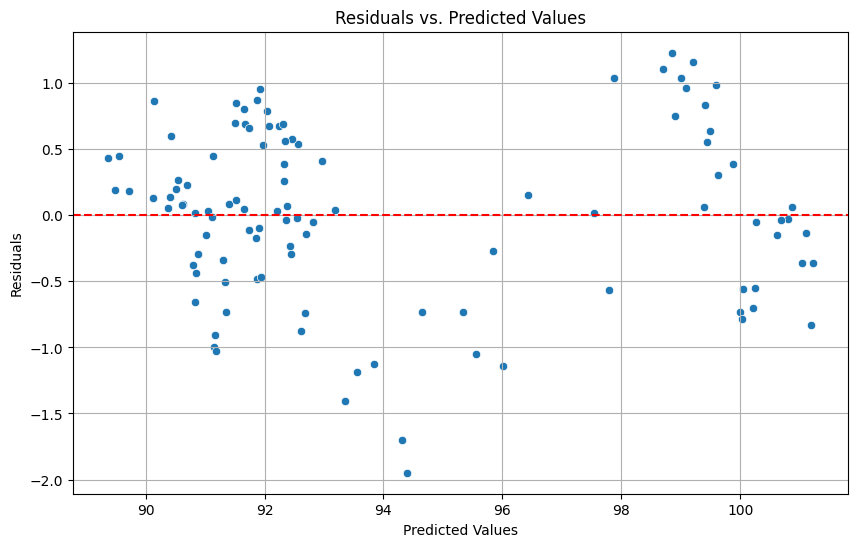

Durbin-Watson Statistic: 2.21
{'Lagrange multiplier statistic': np.float64(22.672828746388777), 'p-value': np.float64(0.00014717930297071156), 'f-value': np.float64(6.842197293570804), 'f p-value': np.float64(6.338449527864138e-05)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9813860125830681), pvalue=np.float64(0.1354922889459373))
Kolmogorov: KstestResult(statistic=np.float64(0.12159402806230124), pvalue=np.float64(0.07533680086912722), statistic_location=np.float64(1.0391314378766339), statistic_sign=np.int8(1))


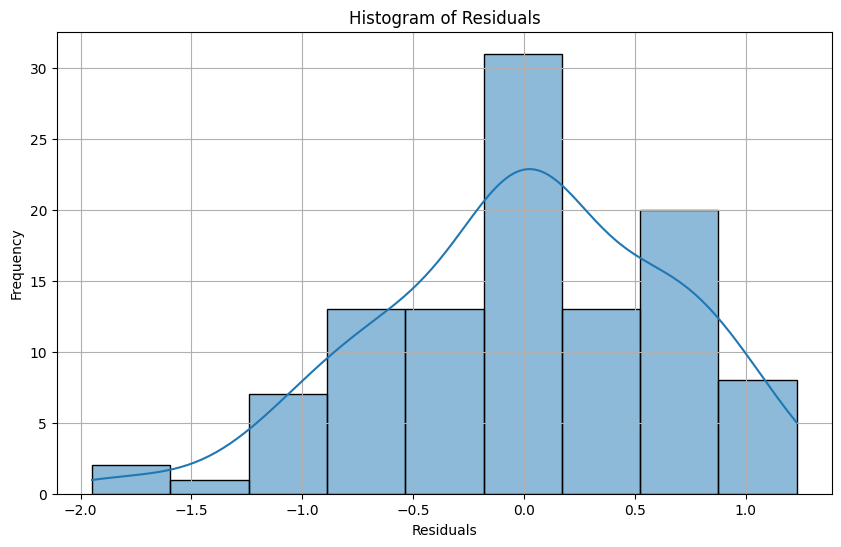

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from scipy.stats import kstest
import stemgraphic

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear, y=residualslinear)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

dw = durbin_watson(residualslinear)
print(f'Durbin-Watson Statistic: {dw:.2f}')

X_const = sm.add_constant(X_train)
bp_test = het_breuschpagan(residualslinear, X_const)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

shapiro = stats.shapiro(residualslinear)
print(f'Shapiro-Wilk Test: {shapiro}')

# white_test = het_white(residualslinear, X_const)
# print(f'White Test: {white_test}')

ks_test = kstest(residualslinear, 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslinear, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

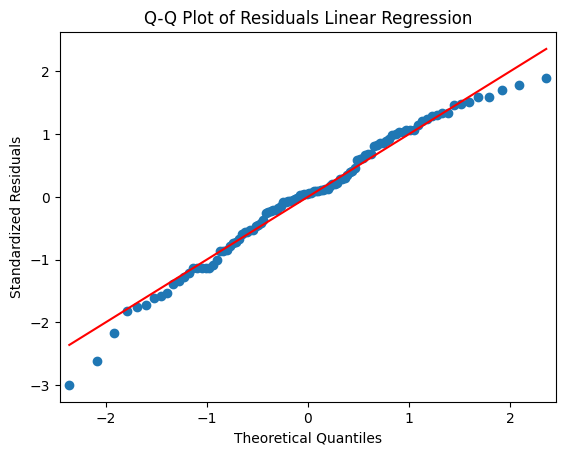

In [ ]:
sm.qqplot(residualslinear, line='s', fit=True)
plt.title('Q-Q Plot of Residuals Linear Regression')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.show()

In [ ]:
# Find indices where residuals are less than -1.5
indices_less_than_neg_1_5 = residualslinear[residualslinear < -1.5].index

print("Indices where residualslinear < -1.5:")
print(indices_less_than_neg_1_5)

Indices where residualslinear < -1.5:
Index([52, 62], dtype='int64')


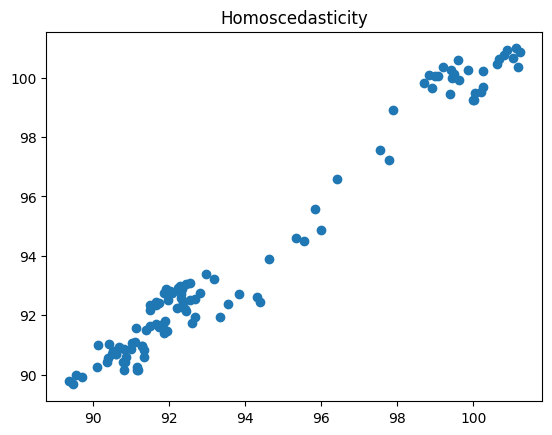

In [ ]:
plt.scatter(x=y_predlinear, y=y_train)
plt.title('Homoscedasticity')
plt.show()

In [ ]:
vif = calculate_vif(X_train)
print(vif)

        Column       VIF
0   EX_AVG_USD  1.371958
1      IMI_IDX  3.939751
2       policy  1.318035
3  oilwtiprice  3.986176


In [ ]:
X_const_power = sm.add_constant(X_train)  # เพิ่ม constant สำหรับ intercept

# Fit โมเดล OLS หลัก (จาก statsmodels เพื่อ consistency)
model_sm = sm.OLS(y_train, X_const_power).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                CPI_IDX   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     851.9
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           6.03e-78
Time:                        07:48:12   Log-Likelihood:                -106.76
No. Observations:                 108   AIC:                             223.5
Df Residuals:                     103   BIC:                             236.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          92.8286      0.075   1237.776      

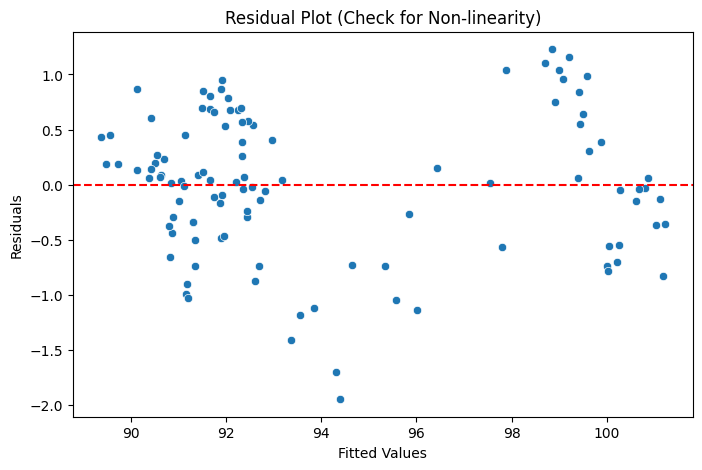

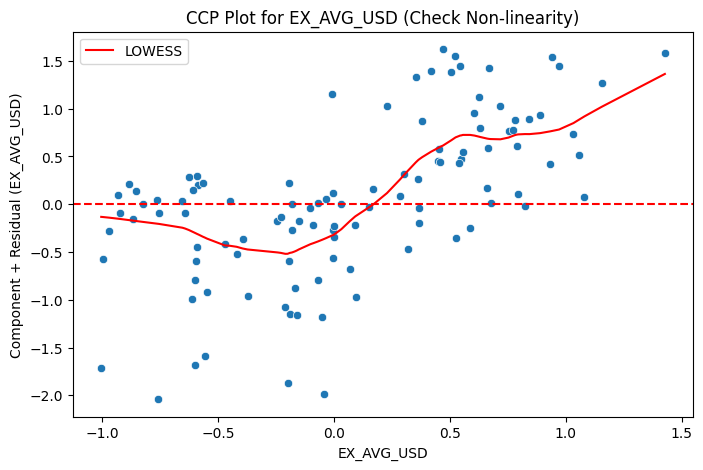

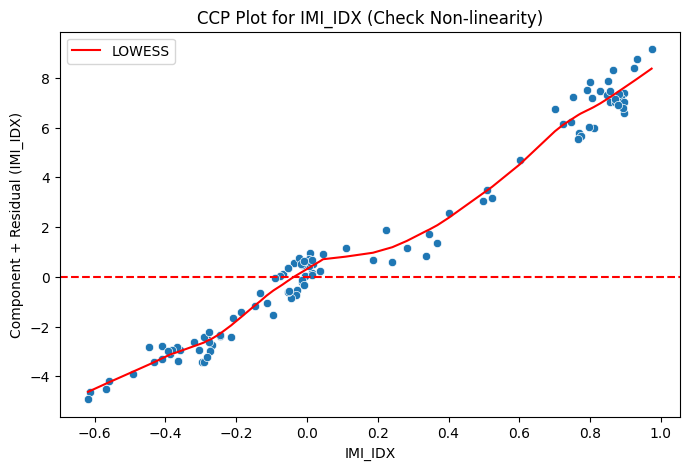

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide



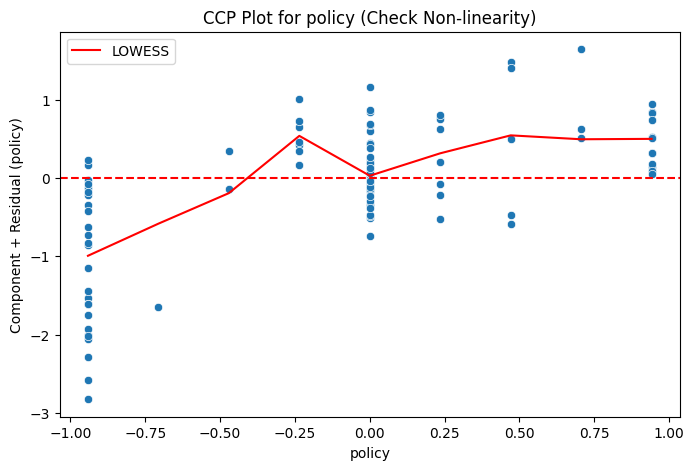

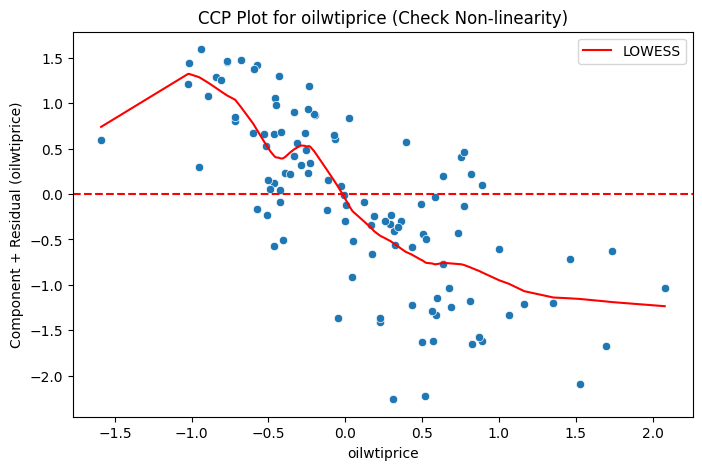

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# สมมติว่า X_train_log, y_train_log ได้ถูกกำหนดไว้แล้ว
X = sm.add_constant(X_train)  # เพิ่ม constant ถ้ายังไม่มี

# Fit โมเดล OLS
model_ols = sm.OLS(y_train, X).fit()

# ดึง residuals และ fitted values
residuals = model_ols.resid
fitted = model_ols.fittedvalues

# 1. Residual Plot (ตรวจสอบ non-linearity โดยรวม)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Check for Non-linearity)')
plt.show()
# การแปลผล: ถ้ามี pattern (เช่น โค้ง, U-shape) = มี non-linearity

# 2. Component-Plus-Residual Plot (CCP) สำหรับแต่ละตัวแปรใน X_train_log
for col in X_train.columns:
    # คำนวณ component + residual = beta * x_i + residual
    component = model_ols.params[col] * X_train[col]
    ccp = component + residuals

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_train[col], y=ccp)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel(col)
    plt.ylabel(f'Component + Residual ({col})')
    plt.title(f'CCP Plot for {col} (Check Non-linearity)')
    # เพิ่ม lowess curve เพื่อดู trend
    lowess = sm.nonparametric.lowess(ccp, X_train[col], frac=0.3)
    plt.plot(lowess[:, 0], lowess[:, 1], color='red', label='LOWESS')
    plt.legend()
    plt.show()
    # การแปลผล: ถ้า LOWESS curve ไม่เป็นเส้นตรง = มี non-linearity สำหรับตัวแปรนั้น

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_predloo = cross_val_predict(
    estimator=linear_model,
    X=X_train,
    y=y_train,
    cv=loo,
)

In [ ]:
r2lnloo = r2_score(y_train,y_predloo)
mselnloo = mean_squared_error(y_train, y_predloo)
maelnloo = mean_absolute_error(y_train, y_predloo)
rmselnloo = np.sqrt(mselnloo)

print(f'R-squared Score (LN): {r2lnloo:.3f}')
print(f'Mean Squared Error (LN): {mselnloo:.3f}')
print(f'Mean Absolute Error (LN): {maelnloo:.3f}')
print(f'Root Mean Squared Error (LN): {rmselnloo:.3f}')

R-squared Score (LN): 0.968
Mean Squared Error (LN): 0.466
Mean Absolute Error (LN): 0.538
Root Mean Squared Error (LN): 0.683


In [ ]:
from sklearn.inspection import permutation_importance
result = permutation_importance(linear_model, X_train, y_train, scoring='r2', n_repeats=10, random_state=1234)

importance_df = pd.DataFrame(
    {'Feature': X_train.columns, 'Importance': result.importances_mean}
)

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

       Feature  Importance
1      IMI_IDX    2.240908
3  oilwtiprice    0.059120
2       policy    0.043774
0   EX_AVG_USD    0.034161


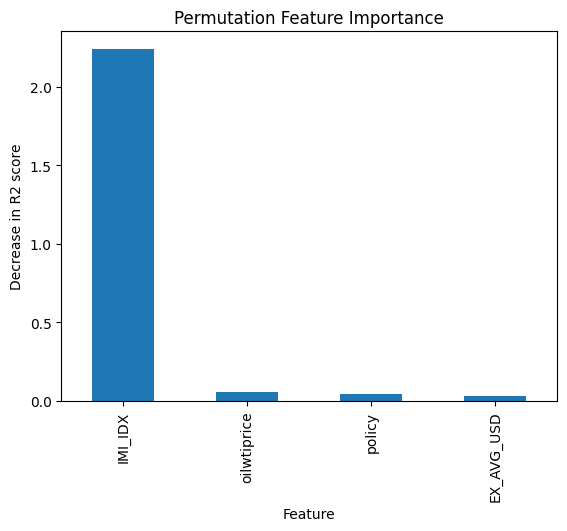

In [ ]:
importance_df.plot.bar(x='Feature', y='Importance', legend=False)
plt.ylabel('Decrease in R2 score')
plt.title('Permutation Feature Importance')
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = X_train.columns

perm_importance = permutation_importance(linear_model, X_test, y_test, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean']
})

perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

print(perm_importance_df)

       Feature  Importance  Normalized_Importance
0   EX_AVG_USD    0.023311               0.012502
3  oilwtiprice    0.055189               0.029599
2       policy    0.107574               0.057695
1      IMI_IDX    1.678467               0.900204


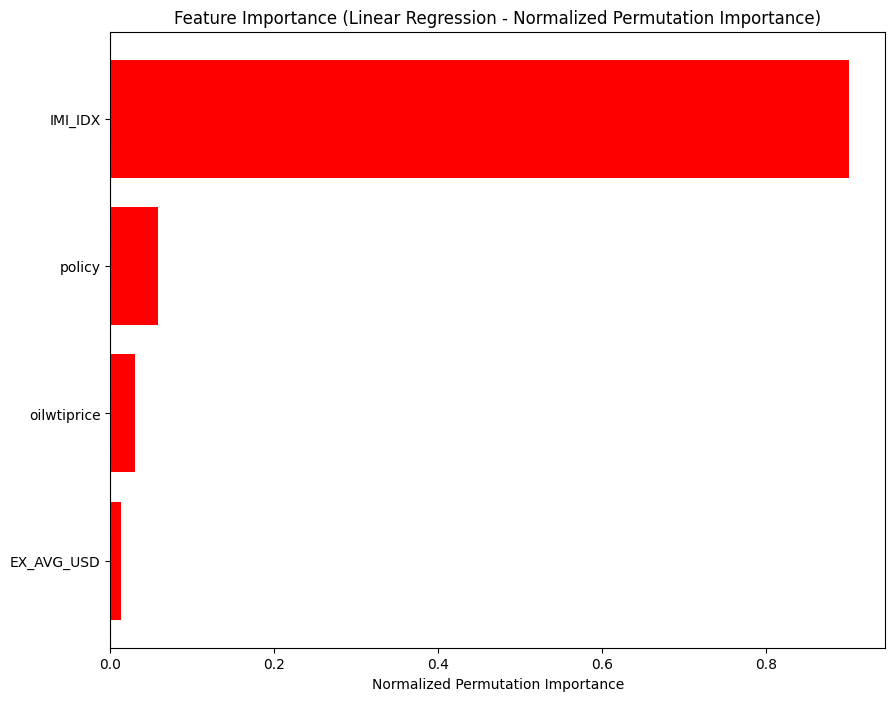

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='red')
plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Linear Regression - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')

EX_AVG_USD


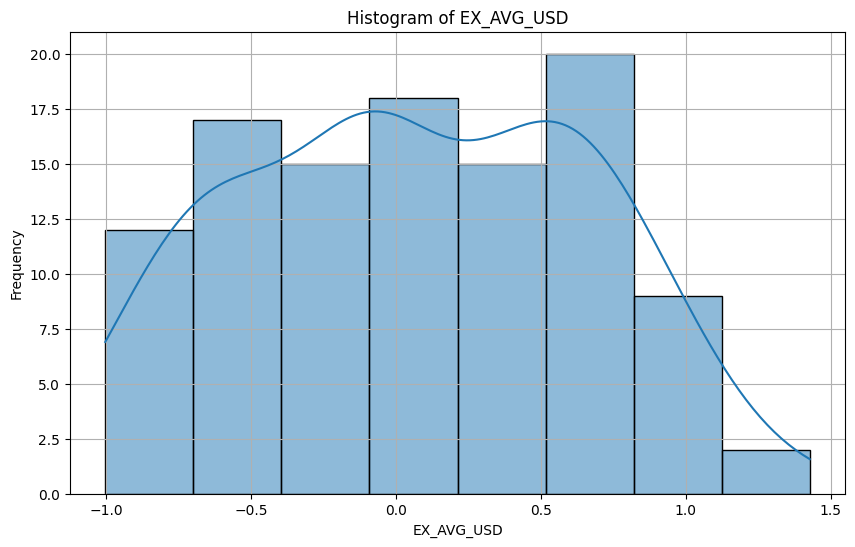

IMI_IDX


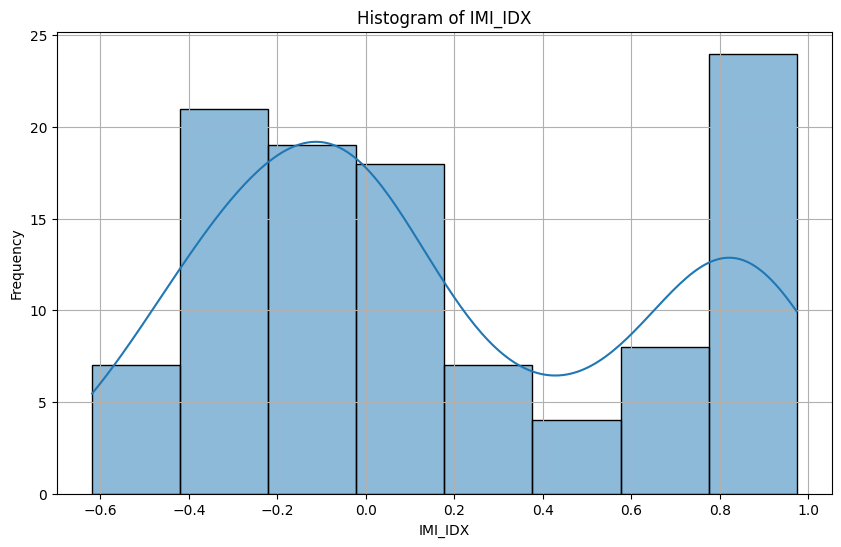

policy


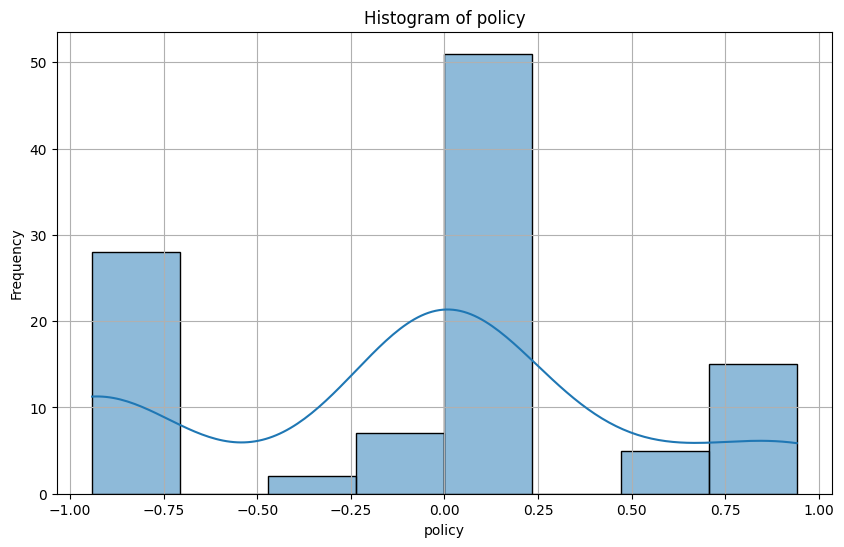

oilwtiprice


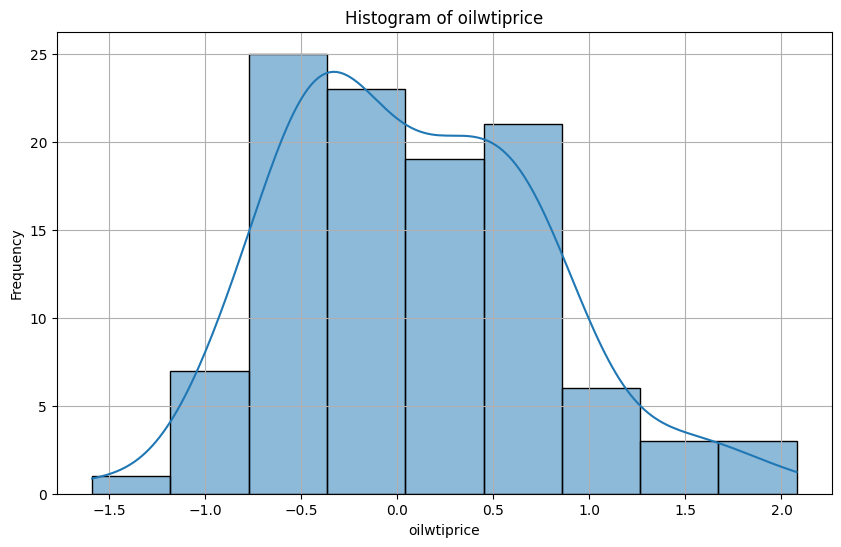

In [ ]:
for i in X_train.columns :
    print(i)
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train[i], kde=True)
    plt.title(f'Histogram of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

In [ ]:
from scipy import stats
for i in X_train.columns :
    print(i)

EX_AVG_USD
IMI_IDX
policy
oilwtiprice


BoxCox Transform Data

In [ ]:
# X = df.drop(columns=['CPI_IDX'])
# y = df['CPI_IDX']
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1711)
# X_train = X_train.reset_index(drop=True)
# X_test = X_test.reset_index(drop=True)
# y_train = y_train.reset_index(drop=True)
# y_test = y_test.reset_index(drop=True)
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# imputer = IterativeImputer(max_iter=10, random_state=1234)
# imputer.fit(X_train)
# X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)

In [ ]:
# feature_col = ['IMI_IDX','oilwtiprice','policy','EX_AVG_USD']
# X_train = X_train[feature_col]
# X_test = X_test[feature_col]

In [ ]:
# from scipy import stats

# # Store fitted lambda values
# fitted_lambda = pd.Series(np.zeros(len(X_train.columns), dtype=np.float64), index=X_train.columns)

# # y_train_boxcox, fitted_lambda['CPI_IDX'] = stats.boxcox(y_train+1)

# X_train_boxcox = pd.DataFrame()
# for col in X_train.columns:
#     X_train_boxcox[col], fitted_lambda[col] = stats.boxcox(X_train[col] + 1)
# fitted_lambda

In [ ]:
# # y_test_boxcox = stats.boxcox(y_test+1, fitted_lambda['CPI_IDX'])
# X_test_boxcox = pd.DataFrame()

# for col in X_test.columns:
#     X_test_boxcox[col] = stats.boxcox(X_test[col]+1, fitted_lambda[col])

In [ ]:
# y_train_boxcox = pd.DataFrame(y_train, index=X_train.index, columns=['CPI_IDX'])
# y_test_boxcox = pd.DataFrame(y_test, index=X_test.index, columns=['CPI_IDX'])

# # y_train_boxcox = pd.DataFrame(y_train_boxcox, index=X_train.index, columns=['CPI_IDX'])
# # y_test_boxcox = pd.DataFrame(y_test_boxcox, index=X_test.index, columns=['CPI_IDX'])

In [ ]:
# fig, axes = plt.subplots(nrows=len(X_train.columns), ncols=2, figsize=(12, 6 * len(X_train.columns)))

# for i, col in enumerate(X_train.columns):
#     # Before transformation
#     sns.histplot(X_train[col], kde=True, ax=axes[i, 0])
#     axes[i, 0].set_title(f'Before Box-Cox: {col}')
#     axes[i, 0].set_xlabel(col)
#     axes[i, 0].set_ylabel('Frequency')

#     # After transformation
#     sns.histplot(X_train_boxcox[col], kde=True, ax=axes[i, 1])
#     axes[i, 1].set_title(f'After Box-Cox: {col}')
#     axes[i, 1].set_xlabel(f'{col} (Box-Cox)')
#     axes[i, 1].set_ylabel('Frequency')

# plt.tight_layout()
# plt.show()

In [ ]:
# # Visualize distribution of y_train before and after Box-Cox transformation
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# # Before transformation
# sns.histplot(y_train, kde=True, ax=axes[0])
# axes[0].set_title('Before Box-Cox: y_train')
# axes[0].set_xlabel('y_train')
# axes[0].set_ylabel('Frequency')

# # After transformation
# sns.histplot(y_train_boxcox, kde=True, ax=axes[1])
# axes[1].set_title('After Box-Cox: y_train')
# axes[1].set_xlabel('y_train (Box-Cox)')
# axes[1].set_ylabel('Frequency')

# plt.tight_layout()
# plt.show()

In [ ]:
# linear_model_boxcox = LinearRegression().fit(X_train_boxcox, y_train_boxcox)
# y_predlinear_boxcox = linear_model_boxcox.predict(X_train_boxcox)
# residualslinearboxcox = y_train_boxcox - y_predlinear_boxcox

# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=y_predlinear_boxcox.flatten(), y=residualslinearboxcox.squeeze())
# plt.axhline(y=0, color='r', linestyle='--')
# plt.title('Residuals vs. Predicted Values (Funnel Test) (boxcox)')
# plt.xlabel('Predicted Values')
# plt.ylabel('Residuals')
# plt.grid(True)
# plt.show()

# dw = durbin_watson(residualslinearboxcox)
# print(f'Durbin-Watson Statistic: {dw[0]:.2f}')

# X_const_boxcox = sm.add_constant(X_train_boxcox)
# bp_test = het_breuschpagan(residualslinearboxcox, X_const_boxcox)
# labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
# print(dict(zip(labels, bp_test)))

# shapiro = stats.shapiro(residualslinearboxcox)
# print(f'Shapiro-Wilk Test: {shapiro}')

# white_test = het_white(residualslinearboxcox, X_const_boxcox)
# print(f'White Test: {white_test}')

# ks_test = kstest(residualslinearboxcox, 'norm')
# print(f'Kolmogorov: {ks_test}')

# plt.figure(figsize=(10, 6))
# sns.histplot(residualslinearboxcox, kde=True)
# plt.title('Histogram of Residuals')
# plt.xlabel('Residuals')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # plot scatter
# sns.scatterplot(x=y_predlinear_boxcox.flatten(), y=y_train_boxcox.to_numpy().flatten())

# # plot reference line y=x
# lims = [
#     np.min([y_predlinear_boxcox.flatten().min(), y_train_boxcox.to_numpy().flatten().min()]),
#     np.max([y_predlinear_boxcox.flatten().max(), y_train_boxcox.to_numpy().flatten().max()])
# ]

# plt.plot(lims, lims, 'r--')  # red dashed line
# plt.xlabel('Predicted (Box-Cox transformed)')
# plt.ylabel('Actual (Box-Cox transformed)')
# plt.title('Predicted vs Actual (Box-Cox transformed)')
# plt.grid(True)
# plt.show()

With Dummies

In [ ]:
X_train_dum = X_train.copy()
X_test_dum = X_test.copy()
y_train_dum = y_train.copy()
y_test_dum = y_test.copy()

In [ ]:
vif_results = calculate_vif(X_train_dum)
print(vif_results)
X_train.info()

        Column       VIF
0   EX_AVG_USD  1.371958
1      IMI_IDX  3.939751
2       policy  1.318035
3  oilwtiprice  3.986176
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EX_AVG_USD   108 non-null    float64
 1   IMI_IDX      108 non-null    float64
 2   policy       108 non-null    float64
 3   oilwtiprice  108 non-null    float64
dtypes: float64(4)
memory usage: 3.5 KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

# # if 'policy' in X_train_dum.columns:
# #     X_train_dum['policy'] = X_train_dum['policy'].astype(str)

# #     le = LabelEncoder()
# #     X_train_dum['policy'] = le.fit_transform(X_train_dum['policy'])

# #     policy_dummies = pd.get_dummies(X_train_dum['policy'], prefix='policy')

# #     X_train_dum = X_train_dum.drop(columns=['policy'])
# #     X_train_dum = pd.concat([X_train_dum, policy_dummies], axis=1)
# # X_train_dum.head()


# if 'policy' in X_train_dum.columns:
#     # แปลงเป็น string ในทั้ง train และ test เพื่อความสอดคล้อง
#     X_train_dum['policy'] = X_train_dum['policy'].astype(str)
#     X_test_dum['policy'] = X_test_dum['policy'].astype(str)

#     # สร้าง LabelEncoder และ fit กับ training set เท่านั้น
#     le = LabelEncoder()
#     X_train_dum['policy'] = le.fit_transform(X_train_dum['policy'])

#     # ใช้ encoder ที่ fit มา แปลงข้อมูล testing set
#     X_test_dum['policy'] = le.transform(X_test_dum['policy'])

#     # แปลงเป็น dummy variables (one-hot encoding) สำหรับ train
#     policy_dummies_train = pd.get_dummies(X_train_dum['policy'], prefix='policy')
#     X_train_dum = X_train_dum.drop(columns=['policy'])
#     X_train_dum = pd.concat([X_train_dum, policy_dummies_train], axis=1)

#     # แปลงเป็น dummy variables สำหรับ test
#     policy_dummies_test = pd.get_dummies(X_test_dum['policy'], prefix='policy')
#     X_test_dum = X_test_dum.drop(columns=['policy'])
#     X_test_dum = pd.concat([X_test_dum, policy_dummies_test], axis=1)

#     # เพื่อความสมบูรณ์ อาจต้องตรวจสอบว่าคอลัมน์ dummy ใน train และ test มีเหมือนกันหรือไม่ และเติม 0 ในคอลัมน์ที่ขาด
#     missing_cols = set(X_train_dum.columns) - set(X_test_dum.columns)
#     for c in missing_cols:
#         X_test_dum[c] = 0

#     X_test_dum = X_test_dum[X_train_dum.columns]

In [ ]:
# if 'policy' in X_train_dum.columns:
#     # แปลงเป็น string ในทั้ง train และ test เพื่อความสอดคล้อง
#     X_train_dum['policy'] = X_train_dum['policy'].astype(str)
#     X_test_dum['policy'] = X_test_dum['policy'].astype(str)

#     # สร้าง LabelEncoder และ fit กับ training set เท่านั้น
#     le = LabelEncoder()
#     X_train_dum['policy'] = le.fit_transform(X_train_dum['policy'])

#     # ใช้ encoder ที่ fit มา แปลงข้อมูล testing set
#     X_test_dum['policy'] = le.transform(X_test_dum['policy'])

#     # แปลงเป็น dummy variables สำหรับ train โดย drop dummy ตัวแรกเพื่อลด multicollinearity
#     policy_dummies_train = pd.get_dummies(X_train_dum['policy'], prefix='policy', drop_first=True)
#     X_train_dum = X_train_dum.drop(columns=['policy'])
#     X_train_dum = pd.concat([X_train_dum, policy_dummies_train], axis=1)

#     # แปลงเป็น dummy variables สำหรับ test ด้วยการใช้ columns เดียวกับ train
#     policy_dummies_test = pd.get_dummies(X_test_dum['policy'], prefix='policy', drop_first=True)
#     X_test_dum = X_test_dum.drop(columns=['policy'])
#     X_test_dum = pd.concat([X_test_dum, policy_dummies_test], axis=1)

#     # เติมคอลัมน์ที่ขาดใน test ด้วย 0
#     missing_cols = set(X_train_dum.columns) - set(X_test_dum.columns)
#     for c in missing_cols:
#         X_test_dum[c] = 0

#     # จัดคอลัมน์ให้เหมือนกันระหว่าง train และ test
#     X_test_dum = X_test_dum[X_train_dum.columns]


In [ ]:
# X_train_dum = X_train_dum.drop(columns=['policy_0','policy_4'])
X_train_dum

,EX_AVG_USD,IMI_IDX,policy,oilwtiprice
0,0.795583,0.769056,0.941176,0.685299
1,0.971951,0.828214,-0.235294,0.773354
2,0.151006,-0.282139,0.000000,-0.390123
3,0.549287,-0.359499,0.000000,-0.516845
4,0.627486,-0.409556,0.000000,-0.460567
...,...,...,...,...
103,0.661883,-0.364050,0.000000,-0.427259
104,-0.393228,0.013652,0.000000,0.255743
105,-0.884961,-0.022753,-0.235294,-0.236600
106,-0.761829,-0.018203,0.000000,-0.201378


In [ ]:
bool_cols = X_train_dum.select_dtypes(include=['bool']).columns
X_train_dum[bool_cols] = X_train_dum[bool_cols].astype(int)

# ตรวจสอบ dtype อีกครั้ง
print(X_train_dum.dtypes)

EX_AVG_USD     float64
IMI_IDX        float64
policy         float64
oilwtiprice    float64
dtype: object


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X_train_dum คือ DataFrame ที่มีตัวแปร numeric และ dummy variables ที่เตรียมพร้อม (drop dummy ตัวใดตัวหนึ่งในแต่ละกลุ่มแล้ว)

# vif_data = pd.DataFrame()
# vif_data['feature'] = X_train_dum.columns
# vif_data['VIF'] = [variance_inflation_factor(X_train_dum.values, i) for i in range(X_train_dum.shape[1])]

# print(vif_data)

In [ ]:
vif_results = calculate_vif(X_train_dum)
print(vif_results)
X_train.info()

        Column       VIF
0   EX_AVG_USD  1.371958
1      IMI_IDX  3.939751
2       policy  1.318035
3  oilwtiprice  3.986176
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EX_AVG_USD   108 non-null    float64
 1   IMI_IDX      108 non-null    float64
 2   policy       108 non-null    float64
 3   oilwtiprice  108 non-null    float64
dtypes: float64(4)
memory usage: 3.5 KB


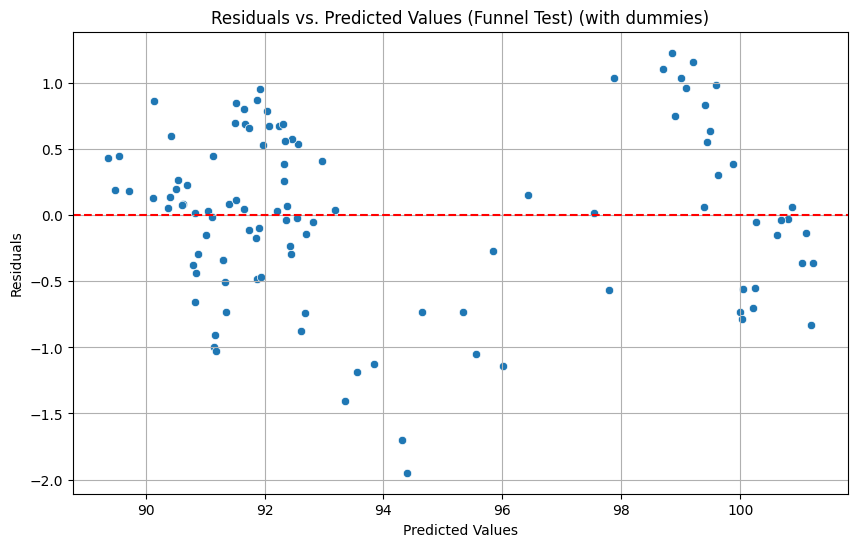

Durbin-Watson Statistic: 2.21
{'Lagrange multiplier statistic': np.float64(22.672828746388777), 'p-value': np.float64(0.00014717930297071156), 'f-value': np.float64(6.842197293570804), 'f p-value': np.float64(6.338449527864138e-05)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9813860125830681), pvalue=np.float64(0.1354922889459373))
White Test: (np.float64(34.4460831698262), np.float64(0.0017742221341180528), np.float64(3.1109207978202846), np.float64(0.0005340465449750241))
Kolmogorov: KstestResult(statistic=np.float64(0.12159402806230124), pvalue=np.float64(0.07533680086912722), statistic_location=np.float64(1.0391314378766339), statistic_sign=np.int8(1))


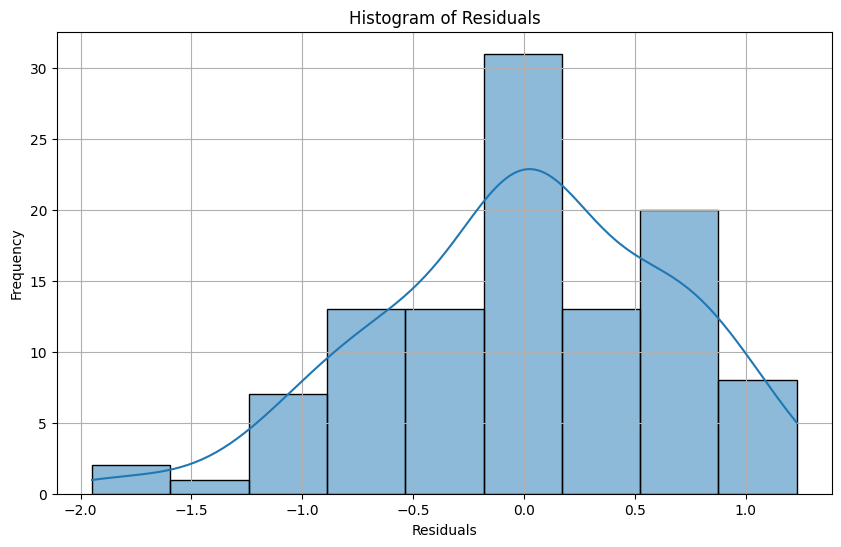

In [ ]:
linear_model_dum = LinearRegression().fit(X_train_dum, y_train_dum)
y_predlinear_dum = linear_model_dum.predict(X_train_dum)
residualslineardum = y_train_dum - y_predlinear_dum

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear_dum.flatten(), y=residualslineardum.squeeze())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Funnel Test) (with dummies)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

dw = durbin_watson(residualslineardum)
print(f'Durbin-Watson Statistic: {dw:.2f}')

X_const_dum = sm.add_constant(X_train_dum)
bp_test = het_breuschpagan(residualslineardum, X_const_dum)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

shapiro = stats.shapiro(residualslineardum)
print(f'Shapiro-Wilk Test: {shapiro}')

white_test = het_white(residualslineardum, X_const_dum)
print(f'White Test: {white_test}')

ks_test = kstest(residualslineardum, 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslineardum, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# this na
y_pred = linear_model_dum.predict(X_test_dum)
y_test = y_test_dum
r2ln = r2_score(y_test,y_pred)
mseln = mean_squared_error(y_test, y_pred)
maeln = mean_absolute_error(y_test, y_pred)
rmseln = np.sqrt(mseln)

print(f'R-squared Score (LN): {r2ln:.3f}')
print(f'Mean Squared Error (LN): {mseln:.3f}')
print(f'Mean Absolute Error (LN): {maeln:.3f}')
print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

R-squared Score (LN): 0.823
Mean Squared Error (LN): 3.217
Mean Absolute Error (LN): 1.521
Root Mean Squared Error (LN): 1.794


In [ ]:
indices_greater_than_5 = residualslineardum[residualslineardum > 5].index
print("Indices where residualslineardum > 5:")
print(indices_greater_than_5)

Indices where residualslineardum > 5:
Index([], dtype='int64')


linear regression noob wa

ridge regression

In [ ]:
from sklearn.linear_model import Ridge
X_train_ridge = X_train.copy()
X_test_ridge = X_test.copy()
y_train_ridge = y_train.copy()
y_test_ridge = y_test.copy()
print(X_train_ridge.isna().sum())
print(X_test_ridge.isna().sum())
print(y_train_ridge.isna().sum())
print(y_test_ridge.isna().sum())

EX_AVG_USD     0
IMI_IDX        0
policy         0
oilwtiprice    0
dtype: int64
EX_AVG_USD     0
IMI_IDX        0
policy         0
oilwtiprice    0
dtype: int64
0
0


In [ ]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_ridge, y_train_ridge)
y_predridge = ridge_model.predict(X_test_ridge)


mse = mean_squared_error(y_test_ridge, y_predridge)
r2 = r2_score(y_test_ridge, y_predridge)
mae = mean_absolute_error(y_test_ridge, y_predridge)
rmse = np.sqrt(mse)

print(f"R-squared Score (Ridge): {r2:.3f}")
print(f"Mean Squared Error (Ridge): {mse:.3f}")
print(f'Mean Absolute Error (Ridge): {mae:.3f}')
print(f'Root Mean Squared Error (Ridge): {rmse:.3f}')

print("Coefficients:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)

R-squared Score (Ridge): 0.818
Mean Squared Error (Ridge): 3.301
Mean Absolute Error (Ridge): 1.548
Root Mean Squared Error (Ridge): 1.817
Coefficients: [ 0.83071592  8.12581873  0.94142359 -0.9118605 ]
Intercept: 92.84606965493296


In [ ]:
from sklearn.linear_model import RidgeCV
from numpy import arange
import warnings

warnings.filterwarnings('ignore')
# กำหนดช่วง alpha
alphas = [0.005 ,  0.1, 1.0, 10.0, 100.0]

ridge_cv = RidgeCV(alphas=alphas)
ridge_cv.fit(X_train, y_train)

print("Best alpha:", ridge_cv.alpha_)
print("Coefficients:", ridge_cv.coef_)

Best alpha: 0.005
Coefficients: [ 0.83499599  8.25403232  0.93144725 -0.99272307]


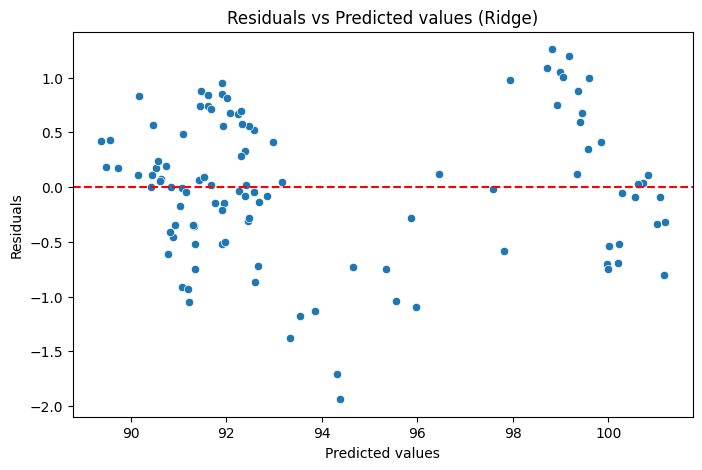

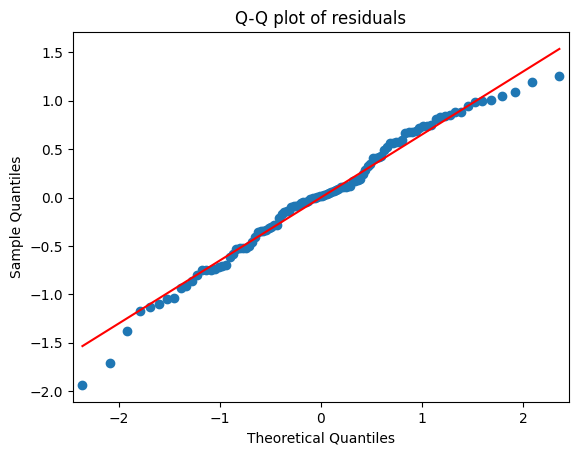

Durbin-Watson Statistic: 2.20
Breusch-Pagan test: {'Lagrange multiplier statistic': np.float64(23.397764537233275), 'p-value': np.float64(0.00010544002086022007), 'f-value': np.float64(7.1214718327261295), 'f p-value': np.float64(4.204140775970288e-05)}
Shapiro-Wilk Test: Statistic=0.9827, p-value=0.1741
Kolmogorov-Smirnov Test: Statistic=0.1207, p-value=0.0790


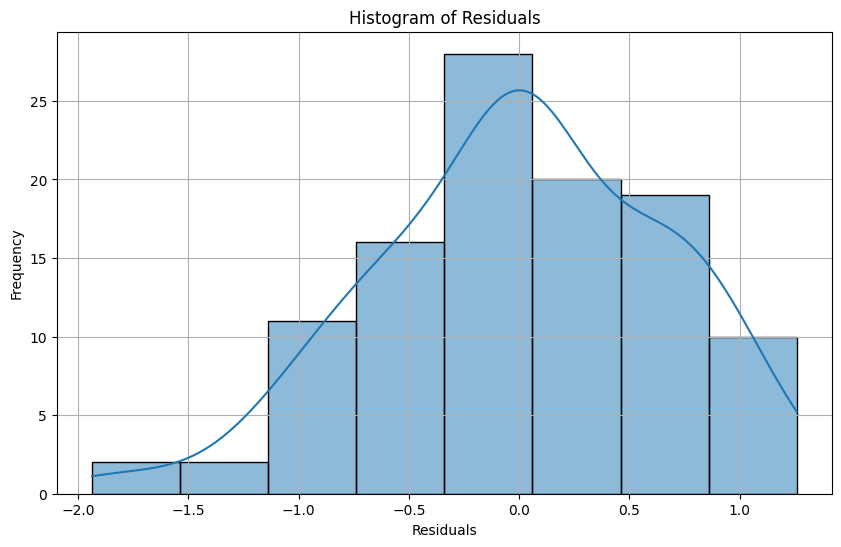

In [ ]:
y_train_pred_ridge = ridge_model.predict(X_train)

residuals = y_train_ridge - y_train_pred_ridge

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_train_pred_ridge, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted values (Ridge)')
plt.show()

sm.qqplot(residuals, line='s')
plt.title('Q-Q plot of residuals')
plt.show()

dw = durbin_watson(residuals)
print(f'Durbin-Watson Statistic: {dw:.2f}')

X_const = sm.add_constant(X_train)
bp_test = het_breuschpagan(residuals, X_const)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print("Breusch-Pagan test:", dict(zip(labels, bp_test)))

# white_test = het_white(residuals, X_const)
# labels_white = ['White LM Statistic', 'White LM p-value', 'White F-Statistic', 'White F-Test p-value']
# print("White test:", dict(zip(labels_white, white_test)))

shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: Statistic={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}')

ks_test = kstest(residuals, 'norm')
print(f'Kolmogorov-Smirnov Test: Statistic={ks_test.statistic:.4f}, p-value={ks_test.pvalue:.4f}')

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
r2ln = r2_score(y_test,y_pred)
mseln = mean_squared_error(y_test, y_pred)
maeln = mean_absolute_error(y_test, y_pred)
rmseln = np.sqrt(mseln)

print(f'R-squared Score (LN): {r2ln:.3f}')
print(f'Mean Squared Error (LN): {mseln:.3f}')
print(f'Mean Absolute Error (LN): {maeln:.3f}')
print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

R-squared Score (LN): 0.823
Mean Squared Error (LN): 3.217
Mean Absolute Error (LN): 1.521
Root Mean Squared Error (LN): 1.794


In [ ]:
X_train_power = X_train.copy()
X_test_power = X_test.copy()
y_train_power = y_train.copy()
y_test_power = y_test.copy()

In [ ]:
from sklearn.preprocessing import PowerTransformer
box_cox_transformer = PowerTransformer()
y_train_power = box_cox_transformer.fit_transform(y_train.values.reshape(-1, 1))
y_test_power = box_cox_transformer.transform(y_test.values.reshape(-1, 1))

In [ ]:
y_train_power = pd.DataFrame(y_train_power, index=X_train.index, columns=['CPI_IDX'])
y_test_power = pd.DataFrame(y_test_power, index=X_test.index, columns=['CPI_IDX'])

In [ ]:
y_train_power = y_train_power.squeeze()
y_test_power = y_test_power.squeeze()

In [ ]:
print(y_train_power)
print(y_train)

0      5.551115e-17
1      5.551115e-17
2     -5.551115e-17
3     -5.551115e-17
4     -5.551115e-17
           ...     
103   -5.551115e-17
104   -2.775558e-17
105   -2.775558e-17
106   -2.775558e-17
107   -2.775558e-17
Name: CPI_IDX, Length: 108, dtype: float64
0       99.48
1      100.13
2       90.86
3       90.85
4       91.03
        ...  
103     90.42
104     92.32
105     92.87
106     92.92
107     93.00
Name: CPI_IDX, Length: 108, dtype: float64


In [ ]:
X_train_log = X_train.copy()
X_test_log = X_test.copy()
y_train_log = y_train.copy()
y_test_log = y_test.copy()
# y_train_log = np.log1p(y_train_log)
# y_test_log = np.log1p(y_test_log)

# i=2
# y_train_log = y_train_log **i
# y_test_log = y_test_log ** i


i = 0.123
y_train_log = (y_train_log**i - 1) / i
y_test_log = (y_test_log**i - 1) / i

# i = 0.688733
# X_train_log['EX_AVG_USD'] = (X_train_log['EX_AVG_USD']**i - 1) / i
# X_test_log['EX_AVG_USD'] = (X_test_log['EX_AVG_USD']**i - 1) / i

# i = 0.475407
# X_train_log['oilwtiprice'] = (X_train_log['oilwtiprice']**i - 1) / i
# X_test_log['oilwtiprice'] = (X_test_log['oilwtiprice']**i - 1) / i

# i = -1.514477
# X_train_log['IMI_IDX'] = (X_train_log['IMI_IDX']**i - 1) / i
# X_test_log['IMI_IDX'] = (X_test_log['IMI_IDX']**i - 1) / i

# i = 0.830371
# X_train_log['policy'] = (X_train_log['policy']**i - 1) / i
# X_test_log['policy'] = (X_test_log['policy']**i - 1) / i

In [ ]:
# from sklearn.preprocessing import PowerTransformer
# boxbox = PowerTransformer()
# y_train_log = boxbox.fit_transform(y_train.values.reshape(-1, 1))
# y_test_log = boxbox.transform(y_test.values.reshape(-1, 1))

In [ ]:
# @title
# from sklearn.preprocessing import PowerTransformer

# # Initialize PowerTransformer with Yeo-Johnson method
# yeo_johnson_transformer = PowerTransformer(method='yeo-johnson')

# # Apply Yeo-Johnson transformation to y_train_log and y_test_log
# y_train_yeojohnson = yeo_johnson_transformer.fit_transform(y_train_log.values.reshape(-1, 1))
# y_test_yeojohnson = yeo_johnson_transformer.transform(y_test_log.values.reshape(-1, 1))

# # Convert back to pandas Series if needed
# y_train_yeojohnson = pd.Series(y_train_yeojohnson.flatten(), index=y_train_log.index)
# y_test_yeojohnson = pd.Series(y_test_yeojohnson.flatten(), index=y_test_log.index)

# print("y_train_log after Yeo-Johnson transformation:")
# print(y_train_yeojohnson.head())
# print("\ny_test_log after Yeo-Johnson transformation:")
# print(y_test_yeojohnson.head())


# y_train_log = y_train_yeojohnson
# y_test_log = y_test_yeojohnson

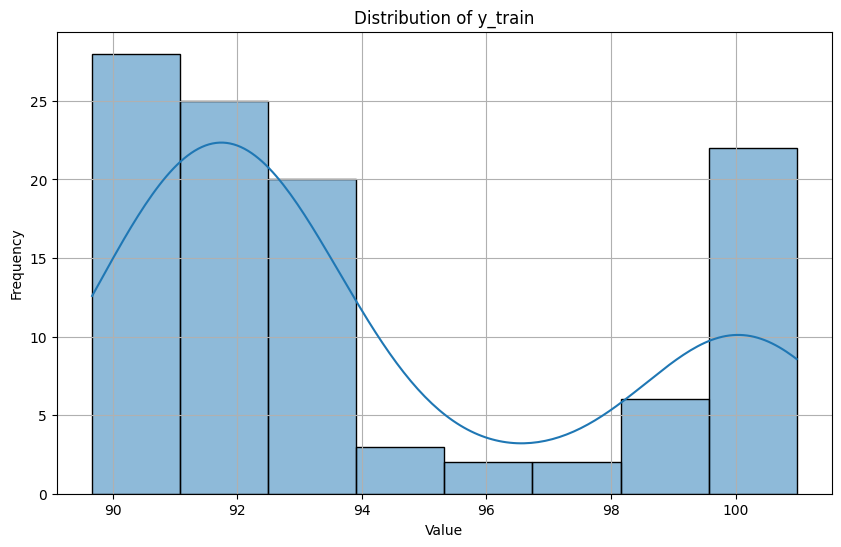

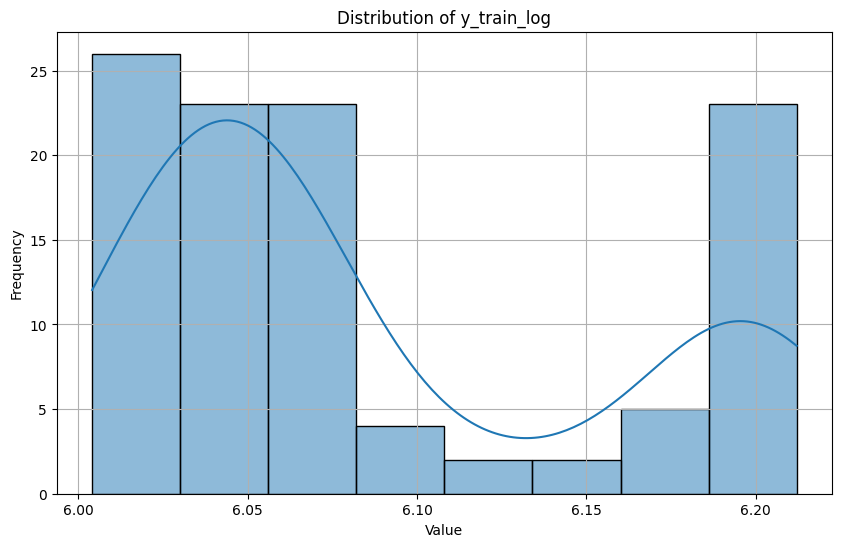

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True)
plt.title('Distribution of y_train')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(y_train_log, kde=True)
plt.title('Distribution of y_train_log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)

X_train_log = pd.DataFrame(X_train_log_scaled, columns=X_train_log.columns)
X_test_log = pd.DataFrame(X_test_log_scaled, columns=X_test_log.columns)

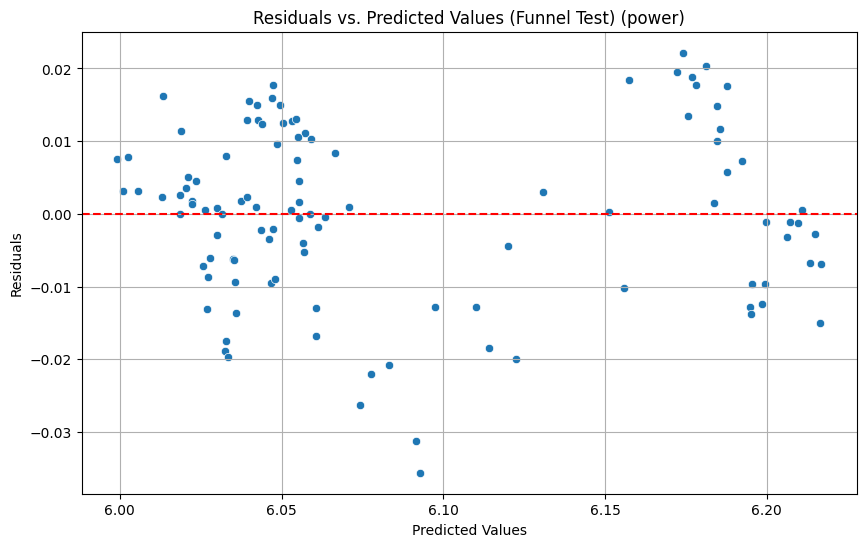

RunTest
Z-test statistic: 1.0297729393831099
P-value: 0.30311660654484573
Durbin-Watson Statistic: 2.2006543296034278
{'Lagrange multiplier statistic': np.float64(21.944599535743365), 'p-value': np.float64(0.0002055740724462755), 'f-value': np.float64(6.5663913594835535), 'f p-value': np.float64(9.530127174452823e-05)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9790255122677133), pvalue=np.float64(0.08584850884828528))
White Test: (np.float64(32.97317678701776), np.float64(0.002906771683819362), np.float64(2.9194372567334215), np.float64(0.0010548187645001302))
Kolmogorov: KstestResult(statistic=np.float64(0.4911621551836103), pvalue=np.float64(1.4785175951581742e-24), statistic_location=np.float64(0.02215500401267434), statistic_sign=np.int8(1))


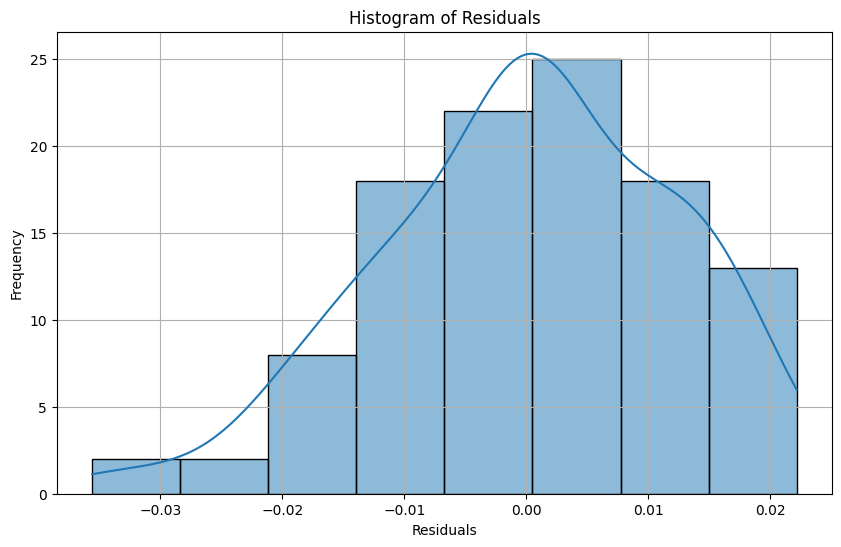

In [ ]:
from statsmodels.sandbox.stats.runs import runstest_1samp

linear_model_power = LinearRegression().fit(X_train_log, y_train_log)
y_predlinear_power = linear_model_power.predict(X_train_log)
residualslinearpower = y_train_log - y_predlinear_power

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear_power.flatten(), y=residualslinearpower.squeeze())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Funnel Test) (power)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

z_stat, p_value = runstest_1samp(residualslinearpower, correction=False)
print('RunTest')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

dw = durbin_watson(residualslinearpower)
print(f'Durbin-Watson Statistic: {dw}')

X_const_power = sm.add_constant(X_train_log)
bp_test = het_breuschpagan(residualslinearpower, X_const_power)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))



shapiro = stats.shapiro(residualslinearpower)
print(f'Shapiro-Wilk Test: {shapiro}')

white_test = het_white(residualslinearpower, X_const_power)
print(f'White Test: {white_test}')

ks_test = kstest(residualslinearpower, 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslinearpower, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

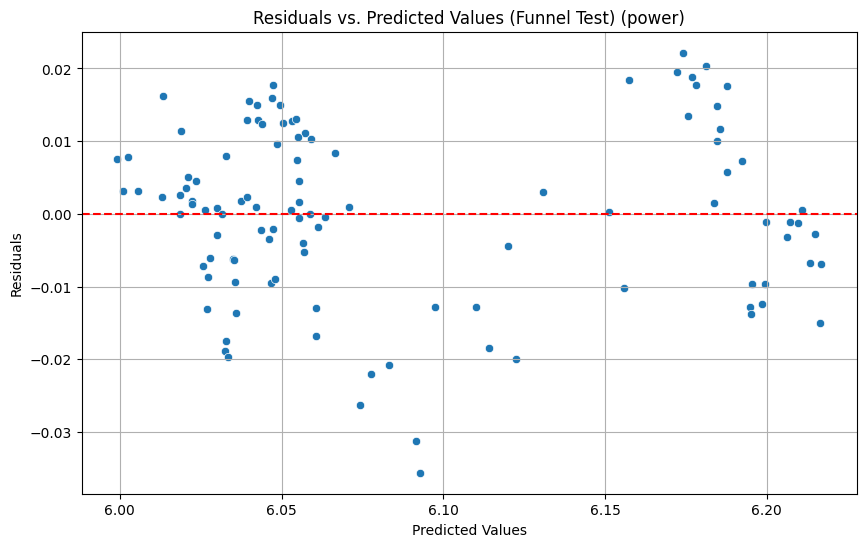

RunTest
Z-test statistic: 1.0297729393831099
P-value: 0.30311660654484573
Durbin-Watson Statistic: 2.2006543296034278
Breusch-Pagan Test:
{'Lagrange multiplier statistic': np.float64(21.944599535743365), 'p-value': np.float64(0.0002055740724462755), 'f-value': np.float64(6.5663913594835535), 'f p-value': np.float64(9.530127174452823e-05)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9790255122677133), pvalue=np.float64(0.08584850884828528))
White Test: (np.float64(32.97317678701776), np.float64(0.002906771683819362), np.float64(2.9194372567334215), np.float64(0.0010548187645001302))
Kolmogorov: KstestResult(statistic=np.float64(0.4911621551836103), pvalue=np.float64(1.4785175951581742e-24), statistic_location=np.float64(0.02215500401267434), statistic_sign=np.int8(1))


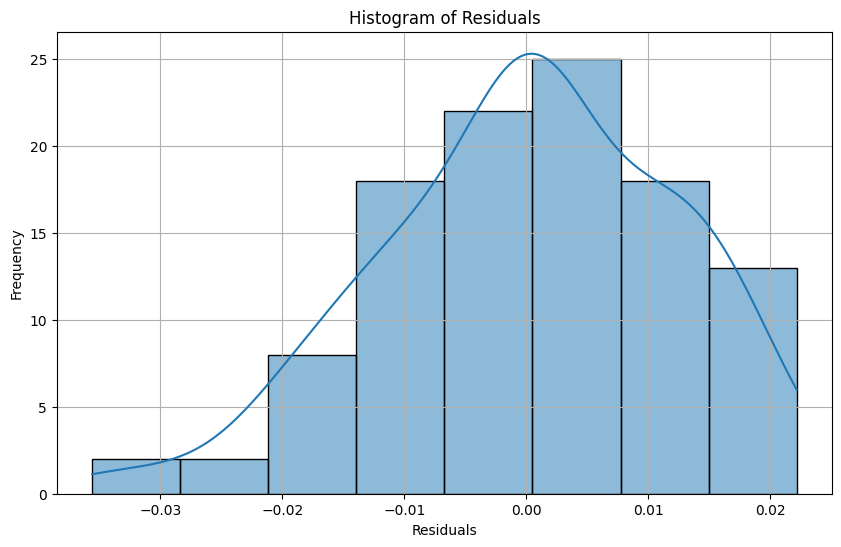


Park Test Model Summary (p-values < 0.05 on coefs indicate heteroscedasticity):
                            OLS Regression Results                            
Dep. Variable:                CPI_IDX   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     5.401
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           0.000547
Time:                        07:48:28   Log-Likelihood:                -251.72
No. Observations:                 108   AIC:                             513.4
Df Residuals:                     103   BIC:                             526.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [ ]:
# @title
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, het_goldfeldquandt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.sandbox.stats.runs import runstest_1samp
from sklearn.linear_model import LinearRegression

# Assuming X_train_log and y_train_log are defined
X_const_power = sm.add_constant(X_train_log)
linear_model_power = LinearRegression().fit(X_train_log, y_train_log)
y_predlinear_power = linear_model_power.predict(X_train_log)
residualslinearpower = y_train_log - y_predlinear_power

# Fit with statsmodels for diagnostics
model_sm = sm.OLS(y_train_log, X_const_power).fit()

# Existing tests (from your code)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear_power.flatten(), y=residualslinearpower.squeeze())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Funnel Test) (power)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

z_stat, p_value = runstest_1samp(residualslinearpower, correction=False)
print('RunTest')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

dw = durbin_watson(residualslinearpower)
print(f'Durbin-Watson Statistic: {dw}')

bp_test = het_breuschpagan(residualslinearpower, X_const_power)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print('Breusch-Pagan Test:')
print(dict(zip(labels, bp_test)))

shapiro = stats.shapiro(residualslinearpower)
print(f'Shapiro-Wilk Test: {shapiro}')

white_test = het_white(residualslinearpower, X_const_power)
print(f'White Test: {white_test}')

ks_test = stats.kstest(residualslinearpower, 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslinearpower, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Additional Heteroscedasticity Tests (from previous)
# Park Test
log_res_sq = np.log(np.abs(residualslinearpower)**2 + 1e-10)
log_X = np.log(np.abs(X_train_log) + 1e-10)
X_log_const = sm.add_constant(log_X)
park_model = sm.OLS(log_res_sq, X_log_const).fit()
print('\nPark Test Model Summary (p-values < 0.05 on coefs indicate heteroscedasticity):')
print(park_model.summary())

# Glejser Test
abs_res = np.abs(residualslinearpower)
glejser_model = sm.OLS(abs_res, X_const_power).fit()
print('\nGlejser Test Model Summary (p-values < 0.05 on coefs indicate heteroscedasticity):')
print(glejser_model.summary())

# Spearman Rank Correlation Test
spearman_corr, spearman_p = stats.spearmanr(np.abs(residualslinearpower), y_predlinear_power)
print('\nSpearman Rank Correlation Test:')
print(f'Correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4f}')

# Goldfeld-Quandt Test (default and adjusted splits)
print('\nGoldfeld-Quandt Test (default split=1/3):')
gq_fstat, gq_pvalue, _ = het_goldfeldquandt(residualslinearpower, X_const_power)
print(f'F-statistic: {gq_fstat:.4f}, p-value: {gq_pvalue:.4f}')

print('\nGoldfeld-Quandt Test (split=0.5):')
gq_fstat2, gq_pvalue2, _ = het_goldfeldquandt(residualslinearpower, X_const_power, split=0.5)
print(f'F-statistic: {gq_fstat2:.4f}, p-value: {gq_pvalue2:.4f}')

# Koenker-Bassett Test
influence = model_sm.get_influence()
student_res = influence.resid_studentized_internal
kb_test = het_breuschpagan(student_res**2, X_const_power)
print('\nKoenker-Bassett Test:')
print(dict(zip(labels, kb_test)))

# Interpretation
print("\nSummary of Heteroscedasticity Tests:")
print("Since most tests (Breusch-Pagan, White, Park, Glejser, Spearman, Koenker-Bassett) show p-value < 0.05, heteroscedasticity is likely present.")
print("Goldfeld-Quandt (p-value > 0.05) may be a false negative due to split sensitivity or complex variance pattern.")

# Apply robust SE (White HC3 and Newey-West HAC)
print("\nApplying robust standard errors to address heteroscedasticity:")
# White (HC3)
model_hc3 = sm.OLS(y_train_log, X_const_power).fit(cov_type='HC3')
print("\nModel Summary (White HC3):")
print(model_hc3.summary())

# Newey-West (HAC)
n = len(y_train_log)
maxlags = int(0.75 * n**(1/3))
model_hac = sm.OLS(y_train_log, X_const_power).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
print(f"\nModel Summary (Newey-West HAC with maxlags={maxlags}):")
print(model_hac.summary())

# Additional Recommendation
print("\nRecommendations:")
print("- Inspect residual plots vs. each predictor to identify heteroskedasticity pattern.")
print("- Consider adding quadratic or interaction terms if non-linearity is suspected.")
print("- Try WLS with weights based on identified pattern (e.g., 1/X^2 or 1/fitted^2).")

In [ ]:
# @title
for idx in range(1, X_const_power.shape[1]):  # ลองทุก predictor
    gq_fstat, gq_pvalue, _ = het_goldfeldquandt(y_train_log, X_const_power, idx=idx)
    print(f'\nGoldfeld-Quandt Test (idx={idx}): F-statistic={gq_fstat:.4f}, p-value={gq_pvalue:.4f}')


Goldfeld-Quandt Test (idx=1): F-statistic=0.6208, p-value=0.9508

Goldfeld-Quandt Test (idx=2): F-statistic=2.6611, p-value=0.0004

Goldfeld-Quandt Test (idx=3): F-statistic=0.3184, p-value=0.9999

Goldfeld-Quandt Test (idx=4): F-statistic=1.6582, p-value=0.0399


In [ ]:
# @title
import statsmodels.api as sm
import numpy as np
from scipy import stats  # สำหรับ bootstrap
from sklearn.linear_model import LinearRegression  # ถ้ายังใช้ sklearn อยู่
import pandas as pd # Import pandas

# สมมติว่า X_train_log, y_train_log ได้ถูกกำหนดไว้ (จากโค้ดเดิม)
X_const_power = sm.add_constant(X_train_log)  # เพิ่ม constant สำหรับ intercept

# Fit โมเดล OLS หลัก (จาก statsmodels เพื่อ consistency)
model_sm = sm.OLS(y_train_log, X_const_power).fit()
print("\nOriginal Model Summary (with original SE):")
print(model_sm.summary())

# Define statistic function สำหรับ bootstrap: fit OLS และ return coefficients
def ols_coefficients_bootstrap(X_orig, y_orig, indices):
    X_resampled = X_orig.iloc[indices]  # Resample X using provided indices
    y_resampled = y_orig.iloc[indices]  # Resample y using provided indices
    X_resampled_const = sm.add_constant(X_resampled)
    model = sm.OLS(y_resampled, X_resampled_const).fit()
    return model.params  # Return array ของ coefficients (intercept + predictors)

# Set data to indices for paired bootstrap
indices = np.arange(len(y_train_log))
data = (indices, )  # Tuple with single array of indices

# Statistic lambda with axis as default None to handle extra kwarg
statistic = lambda indices, axis=None: ols_coefficients_bootstrap(X_train_log, y_train_log, indices)

# Run bootstrap (ใช้ random_state เพื่อ reproducibility)
rng = np.random.default_rng(42)  # Seed สำหรับ reproducibility
res = stats.bootstrap(data, statistic,
                      n_resamples=1000,  # เพิ่มได้ถ้าเครื่องแรง
                      confidence_level=0.95,
                      method='BCa',  # Bias-corrected accelerated สำหรับ CI ที่ดี
                      random_state=rng,
                      vectorized=False) # Set vectorized to False as the statistic function is not vectorized

# Extract bootstrap results
bootstrap_se = res.standard_error  # Bootstrap SE สำหรับแต่ละ coefficient
bootstrap_ci_low, bootstrap_ci_high = res.confidence_interval  # 95% CI

# แสดงผล
print("\nBootstrap Standard Errors:")
# Include the constant term in the labels
param_names = ['const'] + list(X_train_log.columns)
for name, se in zip(param_names, bootstrap_se):
    print(f"  {name}: {se:.4f}")

print("\nBootstrap 95% Confidence Intervals (Low, High):")
for name, low, high in zip(param_names, bootstrap_ci_low, bootstrap_ci_high):
    print(f"  {name}: [{low:.4f}, {high:.4f}]")

# เปรียบเทียบกับ original SE
print("\nOriginal SE vs Bootstrap SE:")
for name, orig_se, boot_se in zip(param_names, model_sm.bse, bootstrap_se):
    print(f"  {name}: Original SE = {orig_se:.4f}, Bootstrap SE = {boot_se:.4f}")


Original Model Summary (with original SE):
                            OLS Regression Results                            
Dep. Variable:                CPI_IDX   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     853.6
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           5.46e-78
Time:                        07:48:29   Log-Likelihood:                 325.17
No. Observations:                 108   AIC:                            -640.3
Df Residuals:                     103   BIC:                            -626.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const 


Bootstrap Standard Errors and 95% CI:
const: SE=0.0011, CI=[6.0617, 6.0658]
EX_AVG_USD: SE=0.0020, CI=[0.0109, 0.0184]
IMI_IDX: SE=0.0044, CI=[0.1429, 0.1600]
policy: SE=0.0026, CI=[0.0118, 0.0221]
oilwtiprice: SE=0.0035, CI=[-0.0240, -0.0110]


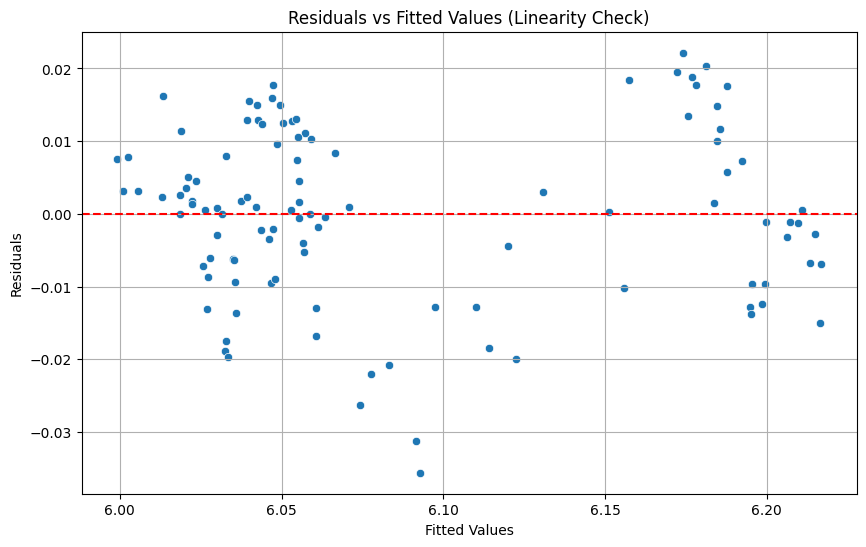


Durbin-Watson Statistic: 2.201
Runs Test: Z-statistic=1.030, p-value=0.303

Breusch-Pagan Test:
{'LM Statistic': np.float64(21.944599535742682), 'LM p-value': np.float64(0.00020557407244633981), 'F-Statistic': np.float64(6.566391359483298), 'F p-value': np.float64(9.530127174456443e-05)}

White Test: (np.float64(32.97317678701992), np.float64(0.0029067716838172782), np.float64(2.9194372567336973), np.float64(0.0010548187644990928))

Goldfeld-Quandt Test (idx=2): F-stat=2.661, p-value=0.000

Goldfeld-Quandt Test (idx=4): F-stat=1.658, p-value=0.040

Park Test Summary (p<0.05 on coefs = Heteroscedasticity):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     5.401
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           

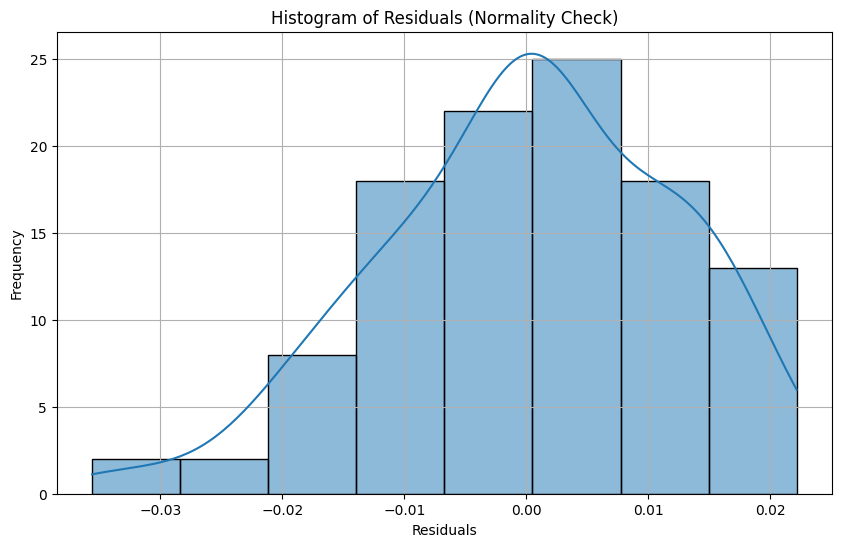

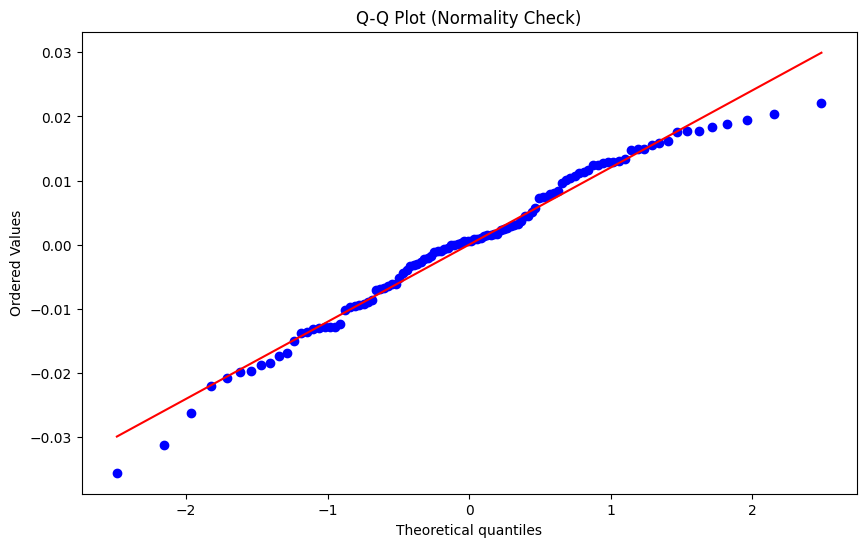


Variance Inflation Factor (VIF):
      Variable       VIF
0   EX_AVG_USD  1.348467
1      IMI_IDX  3.494208
2       policy  1.243330
3  oilwtiprice  3.525032

Recommendations:
- Heteroskedasticity detected (from Breusch-Pagan/White/Spearman/Koenker-Bassett).
  Bootstrap SE/CI are already robust, but consider WLS with weights=1/X2^2 or 1/X4^2 (from Goldfeld-Quandt idx=2,4).


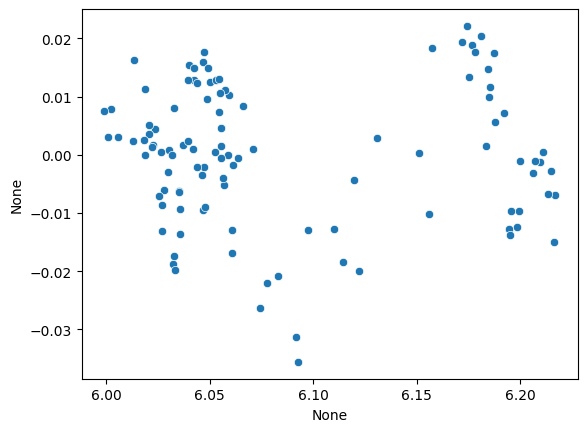

In [ ]:
# @title
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, het_goldfeldquandt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.stats.outliers_influence import variance_inflation_factor

# สมมติว่า X_train_log, y_train_log ได้ถูกกำหนดไว้
X_const_power = sm.add_constant(X_train_log)  # เพิ่ม constant
model_sm = sm.OLS(y_train_log, X_const_power).fit()
residuals = model_sm.resid
fitted = model_sm.fittedvalues

# Bootstrap (จากโค้ดก่อนหน้า)
def ols_coefficients(indices):
    X_resampled = X_train_log.iloc[indices]
    y_resampled = y_train_log.iloc[indices]
    X_resampled_const = sm.add_constant(X_resampled)
    model = sm.OLS(y_resampled, X_resampled_const).fit()
    return model.params

indices = np.arange(len(y_train_log))
data = (indices,)
rng = np.random.default_rng(42)
res = stats.bootstrap(data, ols_coefficients, n_resamples=1000, confidence_level=0.95,
                      method='BCa', random_state=rng, vectorized=False)

bootstrap_se = res.standard_error
bootstrap_ci_low, bootstrap_ci_high = res.confidence_interval
param_names = ['const'] + list(X_train_log.columns)
print("\nBootstrap Standard Errors and 95% CI:")
for name, se, low, high in zip(param_names, bootstrap_se, bootstrap_ci_low, bootstrap_ci_high):
    print(f"{name}: SE={se:.4f}, CI=[{low:.4f}, {high:.4f}]")

# ตรวจสอบ Assumptions หลัง Bootstrap
# 1. Linearity: Residual vs Fitted Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values (Linearity Check)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()
# การแปลผล: Pattern (โค้ง, U-shape) = Non-linearity
# ถ้าไม่ผ่าน: เพิ่ม quadratic/interaction terms เช่น X_train_log['x2_sq'] = X_train_log.iloc[:, 1]**2

# 2. Independence: Durbin-Watson + Runs Test
dw = durbin_watson(residuals)
print(f'\nDurbin-Watson Statistic: {dw:.3f}')
# ~2 = No autocorrelation, <1.5 or >2.5 = Autocorrelation

z_stat, p_value = runstest_1samp(residuals, correction=False)
print(f'Runs Test: Z-statistic={z_stat:.3f}, p-value={p_value:.3f}')
# p-value < 0.05 = Autocorrelation
# ถ้าไม่ผ่าน: ใช้ Newey-West HAC (cov_type='HAC') หรือ GLS

# 3. Homoscedasticity: Breusch-Pagan, White, Goldfeld-Quandt, etc.
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
bp_test = het_breuschpagan(residuals, X_const_power)
print('\nBreusch-Pagan Test:')
print(dict(zip(labels, bp_test)))

white_test = het_white(residuals, X_const_power)
print(f'\nWhite Test: {white_test}')

# Goldfeld-Quandt (ใช้ idx=2, 4 จากผลก่อนหน้า)
for idx in [2, 4]:  # จาก p-value < 0.05 ใน idx=2, 4
    gq_fstat, gq_pvalue, _ = het_goldfeldquandt(residuals, X_const_power, idx=idx)
    print(f'\nGoldfeld-Quandt Test (idx={idx}): F-stat={gq_fstat:.3f}, p-value={gq_pvalue:.3f}')

# Park Test
log_res_sq = np.log(np.abs(residuals)**2 + 1e-10)
log_X = np.log(np.abs(X_train_log) + 1e-10)
X_log_const = sm.add_constant(log_X)
park_model = sm.OLS(log_res_sq, X_log_const).fit()
print('\nPark Test Summary (p<0.05 on coefs = Heteroscedasticity):')
print(park_model.summary())

# Glejser Test
abs_res = np.abs(residuals)
glejser_model = sm.OLS(abs_res, X_const_power).fit()
print('\nGlejser Test Summary (p<0.05 on coefs = Heteroscedasticity):')
print(glejser_model.summary())

# Spearman Rank Correlation
spearman_corr, spearman_p = stats.spearmanr(np.abs(residuals), fitted)
print(f'\nSpearman Rank Correlation Test: Corr={spearman_corr:.3f}, p-value={spearman_p:.3f}')

# Koenker-Bassett
influence = model_sm.get_influence()
student_res = influence.resid_studentized_internal
kb_test = het_breuschpagan(student_res**2, X_const_power)
print('\nKoenker-Bassett Test:')
print(dict(zip(labels, kb_test)))
# การแปลผล: p-value < 0.05 ใน test ใด ๆ = Heteroscedasticity
# Bootstrap ทำให้ SE/CI robust แต่ถ้ายังมี heteroskedasticity ลอง WLS (weights=1/X2^2 หรือ 1/X4^2)

# 4. Normality: Shapiro-Wilk, Kolmogorov-Smirnov, Histogram, Q-Q Plot
shapiro = stats.shapiro(residuals)
print(f'\nShapiro-Wilk Test: Statistic={shapiro.statistic:.3f}, p-value={shapiro.pvalue:.3f}')

standardized_res = (residuals - np.mean(residuals)) / np.std(residuals)
ks_test = stats.kstest(standardized_res, 'norm')
print(f'Kolmogorov-Smirnov Test: Statistic={ks_test.statistic:.3f}, p-value={ks_test.pvalue:.3f}')

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals (Normality Check)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)')
plt.show()
# การแปลผล: p-value < 0.05 หรือ Q-Q Plot ไม่ตรง = Non-normal
# ถ้าไม่ผ่าน: ลอง transform y (เช่น Box-Cox) หรือใช้ GLM

# 5. No Multicollinearity: VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_log.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_log.values, i) for i in range(X_train_log.shape[1])]
print('\nVariance Inflation Factor (VIF):')
print(vif_data)
# VIF > 5-10 = Multicollinearity
# ถ้าไม่ผ่าน: ลบตัวแปรที่มี VIF สูงหรือใช้ PCA

# Recommendations based on assumptions
print("\nRecommendations:")
if any(test[1] < 0.05 for test in [bp_test, white_test, kb_test]) or spearman_p < 0.05:
    print("- Heteroskedasticity detected (from Breusch-Pagan/White/Spearman/Koenker-Bassett).")
    print("  Bootstrap SE/CI are already robust, but consider WLS with weights=1/X2^2 or 1/X4^2 (from Goldfeld-Quandt idx=2,4).")
if p_value < 0.05 or dw < 1.5 or dw > 2.5:
    print("- Autocorrelation detected (from Runs/Durbin-Watson). Use Newey-West HAC:")
    print("  model_hac = sm.OLS(y_train_log, X_const_power).fit(cov_type='HAC', cov_kwds={'maxlags': int(0.75 * len(y_train_log)**(1/3))})")
if shapiro.pvalue < 0.05 or ks_test.pvalue < 0.05:
    print("- Non-normality detected. Consider Box-Cox transformation or GLM (e.g., Gaussian with log link).")
if any(vif_data["VIF"] > 10):
    print("- Multicollinearity detected. Remove high-VIF variables or use PCA.")
if any(sns.scatterplot(x=fitted, y=residuals).get_lines()):  # Simplified linearity check
    print("- Non-linearity detected. Add quadratic terms (e.g., X2_sq, X4_sq) or use GAM.")

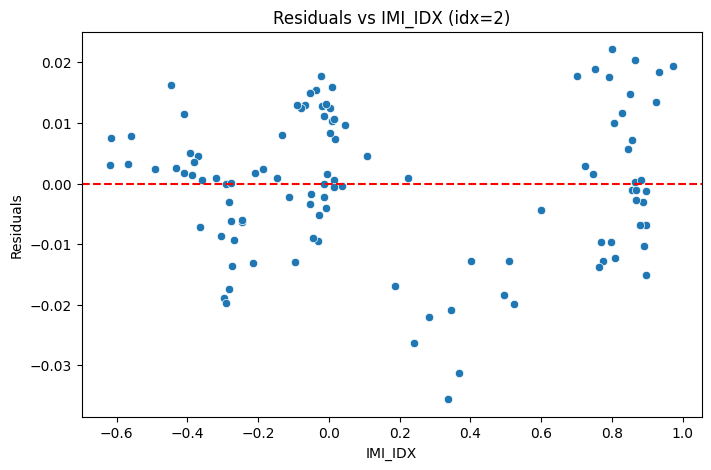

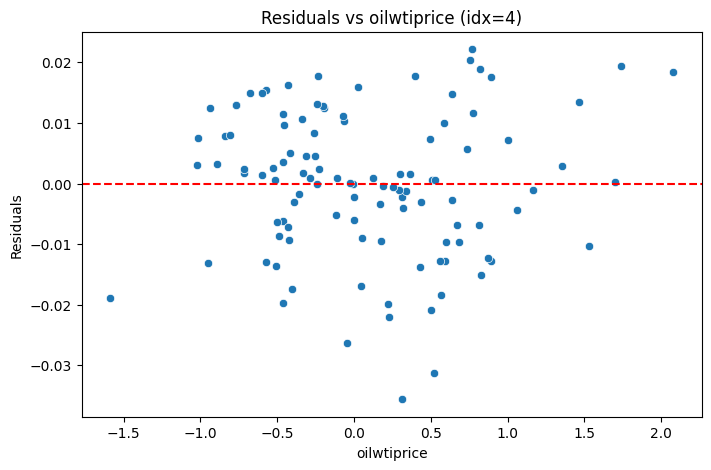

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
for col, idx in zip(X_train_log.columns[[1, 3]], [2, 4]):  # idx=2, 4
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_train_log[col], y=y_train_log - linear_model_power.predict(X_train_log))
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel(col)
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs {col} (idx={idx})')
    plt.show()

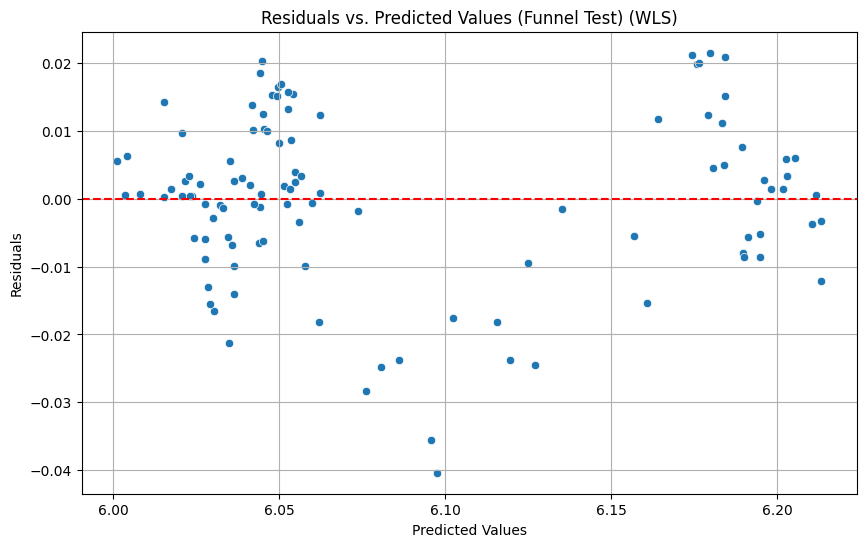

Runs Test:
Z-test statistic: 0.3751719849084951
P-value: 0.7075325638511455
Durbin-Watson Statistic: 2.0847678667031784
Breusch-Pagan Test:
{'Lagrange multiplier statistic': np.float64(22.92934478989512), 'p-value': np.float64(0.00013080878464378067), 'f-value': np.float64(6.940473502661662), 'f p-value': np.float64(5.484253980461033e-05)}
White Test:
{'Lagrange multiplier statistic': np.float64(42.77250360901397), 'p-value': np.float64(9.314945056110377e-05), 'f-value': np.float64(4.356010069953969), 'f p-value': np.float64(6.715542649742697e-06)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9645784003906184), pvalue=np.float64(0.005636495210212541))
Kolmogorov-Smirnov Test: KstestResult(statistic=np.float64(0.4914035512794488), pvalue=np.float64(1.3949769433433817e-24), statistic_location=np.float64(0.021549769233565108), statistic_sign=np.int8(1))


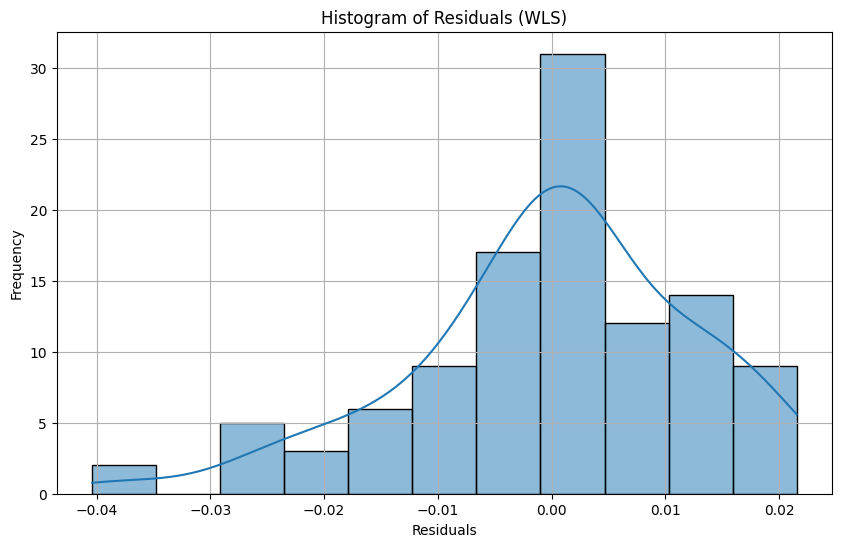


WLS Model Summary:
                            WLS Regression Results                            
Dep. Variable:                CPI_IDX   R-squared:                       0.979
Model:                            WLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     1198.
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.20e-85
Time:                        07:48:43   Log-Likelihood:                 333.49
No. Observations:                 108   AIC:                            -657.0
Df Residuals:                     103   BIC:                            -643.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.0629      0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy import stats
import statsmodels.api as sm

# Step 1: Fit initial OLS model to estimate weights
X_const_power = sm.add_constant(X_train_log)  # Add constant for intercept
ols_model = sm.OLS(y_train_log, X_const_power).fit()
ols_residuals = ols_model.resid
ols_pred = ols_model.predict(X_const_power)

# Step 2: Estimate weights by modeling the variance of residuals
# Regress squared residuals on predictors to estimate variance
squared_residuals = ols_residuals ** 2
var_model = sm.OLS(squared_residuals, X_const_power).fit()
fitted_variance = var_model.fittedvalues

# Ensure weights are positive and non-zero
fitted_variance = np.maximum(fitted_variance, 1e-10)  # Avoid division by zero
weights = 1 / fitted_variance

# Step 3: Fit WLS model with estimated weights
wls_model = sm.WLS(y_train_log, X_const_power, weights=weights).fit()

# Step 4: Compute predictions and residuals from WLS model
y_pred_wls = wls_model.predict(X_const_power)
residuals_wls = y_train_log - y_pred_wls

# Step 5: Diagnostics and Plots

# Plot residuals vs. predicted values (Funnel Test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_wls, y=residuals_wls)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Funnel Test) (WLS)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Runs Test
z_stat, p_value = runstest_1samp(residuals_wls, correction=False)
print('Runs Test:')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

# Durbin-Watson Statistic
dw = durbin_watson(residuals_wls)
print(f'Durbin-Watson Statistic: {dw}')

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals_wls, X_const_power)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print('Breusch-Pagan Test:')
print(dict(zip(labels, bp_test)))

# White Test
white_test = het_white(residuals_wls, X_const_power)
print('White Test:')
print(dict(zip(['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value'], white_test)))

# Shapiro-Wilk Test
shapiro = stats.shapiro(residuals_wls)
print(f'Shapiro-Wilk Test: {shapiro}')

# Kolmogorov-Smirnov Test
ks_test = stats.kstest(residuals_wls, 'norm')
print(f'Kolmogorov-Smirnov Test: {ks_test}')

# Histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_wls, kde=True)
plt.title('Histogram of Residuals (WLS)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Print WLS model summary
print("\nWLS Model Summary:")
print(wls_model.summary())

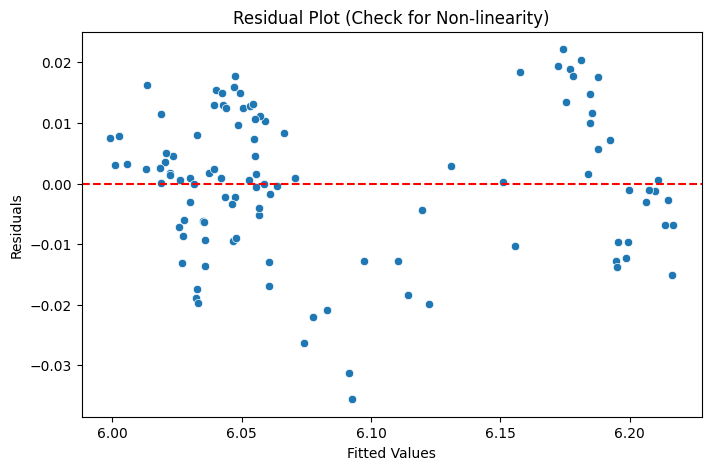

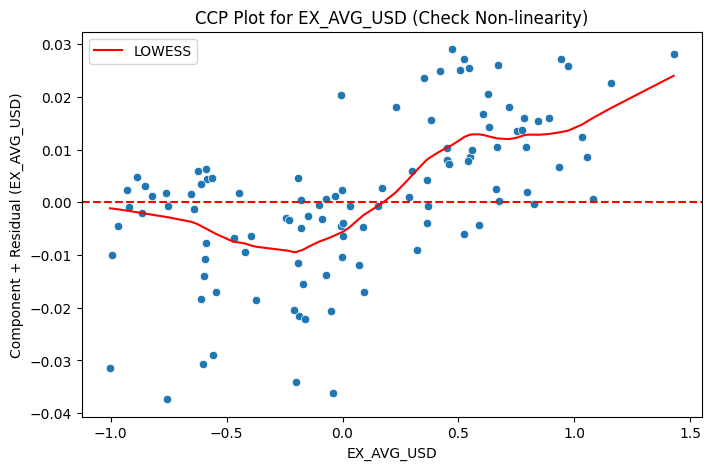

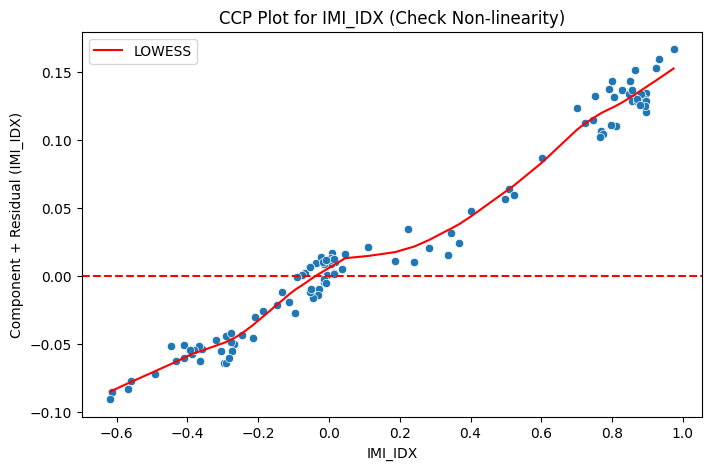

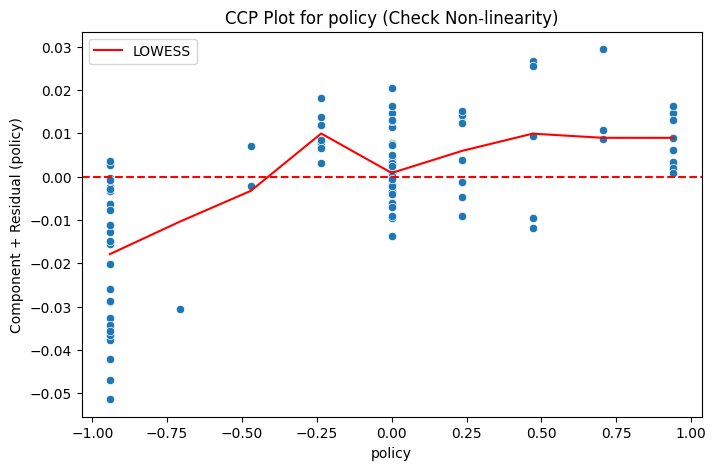

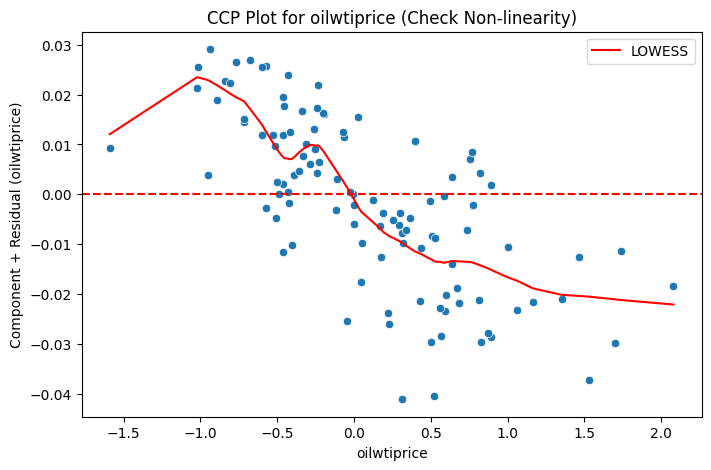

In [ ]:
# @title
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# สมมติว่า X_train_log, y_train_log ได้ถูกกำหนดไว้แล้ว
X = sm.add_constant(X_train_log)  # เพิ่ม constant ถ้ายังไม่มี

# Fit โมเดล OLS
model_ols = sm.OLS(y_train_log, X).fit()

# ดึง residuals และ fitted values
residuals = model_ols.resid
fitted = model_ols.fittedvalues

# 1. Residual Plot (ตรวจสอบ non-linearity โดยรวม)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Check for Non-linearity)')
plt.show()
# การแปลผล: ถ้ามี pattern (เช่น โค้ง, U-shape) = มี non-linearity

# 2. Component-Plus-Residual Plot (CCP) สำหรับแต่ละตัวแปรใน X_train_log
for col in X_train_log.columns:
    # คำนวณ component + residual = beta * x_i + residual
    component = model_ols.params[col] * X_train_log[col]
    ccp = component + residuals

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_train_log[col], y=ccp)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel(col)
    plt.ylabel(f'Component + Residual ({col})')
    plt.title(f'CCP Plot for {col} (Check Non-linearity)')
    # เพิ่ม lowess curve เพื่อดู trend
    lowess = sm.nonparametric.lowess(ccp, X_train_log[col], frac=0.3)
    plt.plot(lowess[:, 0], lowess[:, 1], color='red', label='LOWESS')
    plt.legend()
    plt.show()
    # การแปลผล: ถ้า LOWESS curve ไม่เป็นเส้นตรง = มี non-linearity สำหรับตัวแปรนั้น

In [ ]:
vif = calculate_vif(X_train_power)
print(vif)

        Column       VIF
0   EX_AVG_USD  1.371958
1      IMI_IDX  3.939751
2       policy  1.318035
3  oilwtiprice  3.986176


In [ ]:
# @title
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import kstest, shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Assuming X_train and y_train are already defined and y_train > 0 for transformations

p_values_bp = []  # To store i values where Breusch-Pagan p > 0.05
step = 0.001  # Step size for i

for i in np.arange(-2, 2 + step, step):
    if abs(i) < 1e-6:  # Handle i ≈ 0 as natural log (Box-Cox limit)
        y_trans = np.log(y_train)
    else:
        try:
            y_trans = (y_train**i - 1) / i
        except (ValueError, OverflowError):
            continue  # Skip if transformation fails (e.g., negative y or overflow)

    # Fit model
    model = LinearRegression().fit(X_train, y_trans)

    # Predict and get residuals
    y_pred = model.predict(X_train)
    residuals = y_trans - y_pred

    # Breusch-Pagan test
    X_const = sm.add_constant(X_train)
    bp_test = het_breuschpagan(residuals, X_const)
    bp_pvalue = bp_test[1] # p-value is the second element

    if bp_pvalue > 0.05:
        p_values_bp.append((i, bp_pvalue))

# Print results for Breusch-Pagan test
if p_values_bp:
    print("\nValues of i where residual's Breusch-Pagan p-value > 0.05:")
    for i, p in sorted(p_values_bp, key=lambda x: x[1], reverse=True):  # Sort by highest p-value
        print(f"i = {i:.2f}, residual's Breusch-Pagan p-value = {p:.4f}")
else:
    print("\nNo i in range [-2, 2] with residual's Breusch-Pagan p-value > 0.05")


No i in range [-2, 2] with residual's Breusch-Pagan p-value > 0.05


In [ ]:
# @title
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import kstest, shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, het_white # Import het_white
import statsmodels.api as sm

# Assuming X_train and y_train are already defined and y_train > 0 for transformations

p_values_white = []  # To store i values where White test p > 0.05
step = 0.01  # Step size for i

for i in np.arange(-5, 5 + step, step):
    if abs(i) < 1e-6:  # Handle i ≈ 0 as natural log (Box-Cox limit)
        y_trans = np.log(y_train)
    else:
        try:
            y_trans = (y_train**i - 1) / i
        except (ValueError, OverflowError):
            continue  # Skip if transformation fails (e.g., negative y or overflow)

    # Fit model
    model = LinearRegression().fit(X_train, y_trans)

    # Predict and get residuals
    y_pred = model.predict(X_train)
    residuals = y_trans - y_pred

    # White test
    X_const = sm.add_constant(X_train)
    white_test = het_white(residuals, X_const)
    white_pvalue = white_test[1] # p-value is the second element in het_white result

    if white_pvalue > 0.05:
        p_values_white.append((i, white_pvalue))

# Print results for White test
if p_values_white:
    print("\nValues of i where residual's White test p-value > 0.05:")
    for i, p in sorted(p_values_white, key=lambda x: x[1], reverse=True):  # Sort by highest p-value
        print(f"i = {i:.2f}, residual's White test p-value = {p:.4f}")
else:
    print("\nNo i in range [-2, 2] with residual's White test p-value > 0.05")


No i in range [-2, 2] with residual's White test p-value > 0.05


In [ ]:
# @title
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import kstest, shapiro

p_values = []  # To store i values where p > 0.05
step = 0.01  # Step size for i

for i in np.arange(-2, 2 + step, step):
    if abs(i) < 1e-6:  # Handle i ≈ 0 as natural log (Box-Cox limit)
        y_trans = np.log(y_train)
    else:
        try:
            y_trans = (y_train**i - 1) / i
        except (ValueError, OverflowError):
            continue  # Skip if transformation fails (e.g., negative y or overflow)

    # Fit model
    model = LinearRegression().fit(X_train, y_trans)

    # Predict and get residuals
    y_pred = model.predict(X_train)
    residuals = y_trans - y_pred

    # KS test
    ks = kstest(residuals, 'norm')

    if ks.pvalue > 0.05:
        # Shapiro-Wilk test for normality of y_trans
        shapiro_test_y = shapiro(y_trans)
        # print(f"For i = {i:.2f} (KS p-value = {ks.pvalue:.4f}):")
        # print(f"  Shapiro-Wilk Test on y_trans: Statistic={shapiro_test_y.statistic:.4f}, p-value={shapiro_test_y.pvalue:.4f}")

        p_values.append((i, ks.pvalue))
if p_values:
    print("\nValues of i where residual's KS p-value > 0.05:")
    for i, p in sorted(p_values, key=lambda x: x[1], reverse=True):  # Sort by highest p-value
        print(f"i = {i:.2f}, residual's KS p-value = {p:.4f}")
else:
    print("\nNo i in range [-2, 2] with residual's KS p-value > 0.05")


Values of i where residual's KS p-value > 0.05:
i = 1.10, residual's KS p-value = 0.7184
i = 1.09, residual's KS p-value = 0.6868
i = 1.11, residual's KS p-value = 0.6738
i = 1.08, residual's KS p-value = 0.6271
i = 1.07, residual's KS p-value = 0.5613
i = 1.06, residual's KS p-value = 0.4952
i = 1.12, residual's KS p-value = 0.4866
i = 1.05, residual's KS p-value = 0.4353
i = 1.04, residual's KS p-value = 0.3818
i = 1.03, residual's KS p-value = 0.3347
i = 1.13, residual's KS p-value = 0.3264
i = 1.02, residual's KS p-value = 0.2199
i = 1.14, residual's KS p-value = 0.2058
i = 1.01, residual's KS p-value = 0.1325
i = 1.15, residual's KS p-value = 0.1227
i = 1.00, residual's KS p-value = 0.0753
i = 1.16, residual's KS p-value = 0.0695


y_train_log is already positive, no shift needed
Optimal Box-Cox lambda: -1.999994371326411


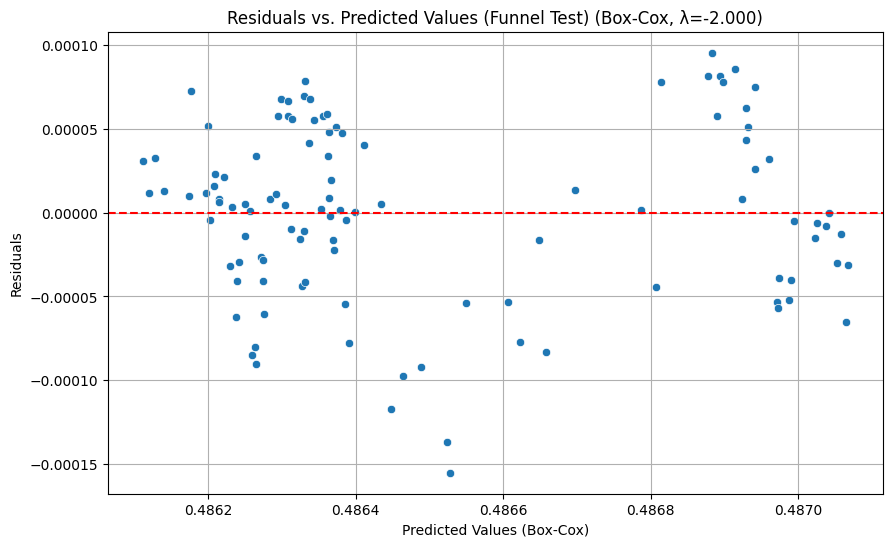

Runs Test:
Z-test statistic: 1.8456913431168886
P-value: 0.06493703490389864
Durbin-Watson Statistic: 2.1895390251626545
Breusch-Pagan Test:
{'Lagrange multiplier statistic': np.float64(21.294097066177663), 'p-value': np.float64(0.0002768607931305902), 'f-value': np.float64(6.323940826411537), 'f p-value': np.float64(0.00013665280127797831)}
White Test:
{'Lagrange multiplier statistic': np.float64(31.632575234997642), 'p-value': np.float64(0.004516463043950149), 'f-value': np.float64(2.751574758391861), 'f p-value': np.float64(0.001913192215306573)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9764797012351341), pvalue=np.float64(0.052404869825768315))
Kolmogorov-Smirnov Test: KstestResult(statistic=np.float64(0.4999619730554249), pvalue=np.float64(1.7321322781327297e-25), statistic_location=np.float64(9.531941461421445e-05), statistic_sign=np.int8(1))


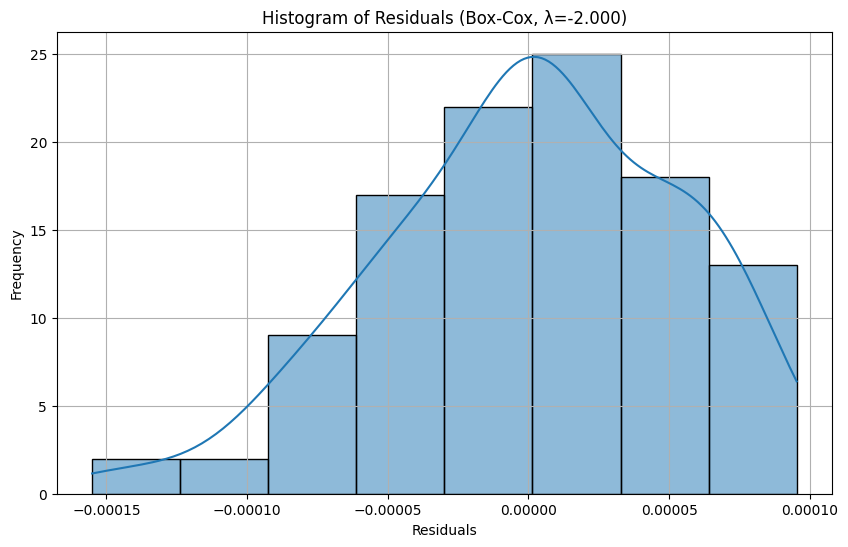


Box-Cox Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     853.0
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           5.68e-78
Time:                        07:49:19   Log-Likelihood:                 911.68
No. Observations:                 108   AIC:                            -1813.
Df Residuals:                     103   BIC:                            -1800.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4864   6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy import stats
import statsmodels.api as sm
import scipy.optimize

# Step 1: Ensure y_train_log is strictly positive
if (y_train_log <= 0).any():
    shift_constant = abs(y_train_log.min()) + 1e-10  # Small constant to avoid zero
    y_train_log_shifted = y_train_log + shift_constant
    print(f"Applied shift of {shift_constant} to make y_train_log positive for Box-Cox transformation")
else:
    y_train_log_shifted = y_train_log
    shift_constant = 0
    print("y_train_log is already positive, no shift needed")

# Step 2: Apply Box-Cox transformation with lambda in [-2, 2]
try:
    # Use minimize_scalar to find the optimal lambda
    def neg_boxcox_llf(lmbda, data):
        return -stats.boxcox_llf(lmbda, data)

    result = scipy.optimize.minimize_scalar(
        neg_boxcox_llf,
        bounds=(-2, 2),  # Restrict lambda to [-2, 2]
        args=(y_train_log_shifted,),
        method='bounded'
    )
    if not result.success:
        raise ValueError("Optimization failed: " + result.message)
    lambda_optimal = result.x
    y_train_boxcox = stats.boxcox(y_train_log_shifted, lmbda=lambda_optimal)
    print(f"Optimal Box-Cox lambda: {lambda_optimal}")
except ValueError as e:
    print(f"Box-Cox transformation failed: {e}")
    # Fallback: use log transformation (lambda=0, which is within [-2, 2])
    y_train_boxcox = np.log(y_train_log_shifted)
    lambda_optimal = 0
    print("Falling back to log transformation (lambda=0)")

# Step 3: Fit linear regression model with Box-Cox transformed y
X_const_power = sm.add_constant(X_train_log)  # Add constant for intercept
boxcox_model = sm.OLS(y_train_boxcox, X_const_power).fit()

# Step 4: Compute predictions and residuals
y_pred_boxcox = boxcox_model.predict(X_const_power)
residuals_boxcox = y_train_boxcox - y_pred_boxcox

# Step 5: Diagnostics and Plots
# Plot residuals vs. predicted values (Funnel Test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_boxcox, y=residuals_boxcox)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residuals vs. Predicted Values (Funnel Test) (Box-Cox, λ={lambda_optimal:.3f})')
plt.xlabel('Predicted Values (Box-Cox)')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Runs Test
z_stat, p_value = runstest_1samp(residuals_boxcox, correction=False)
print('Runs Test:')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

# Durbin-Watson Statistic
dw = durbin_watson(residuals_boxcox)
print(f'Durbin-Watson Statistic: {dw}')

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals_boxcox, X_const_power)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print('Breusch-Pagan Test:')
print(dict(zip(labels, bp_test)))

# White Test
white_test = het_white(residuals_boxcox, X_const_power)
print('White Test:')
print(dict(zip(['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value'], white_test)))

# Shapiro-Wilk Test
shapiro = stats.shapiro(residuals_boxcox)
print(f'Shapiro-Wilk Test: {shapiro}')

# Kolmogorov-Smirnov Test
ks_test = stats.kstest(residuals_boxcox, 'norm')
print(f'Kolmogorov-Smirnov Test: {ks_test}')

# Histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_boxcox, kde=True)
plt.title(f'Histogram of Residuals (Box-Cox, λ={lambda_optimal:.3f})')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Print Box-Cox model summary
print("\nBox-Cox Model Summary:")
print(boxcox_model.summary())

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

linear_model_power = LinearRegression().fit(X_train_power, y_train_log)
y_pred_power = linear_model_power.predict(X_test_power)
r2ln = r2_score(y_test_log,y_pred_power)
mseln = mean_squared_error(y_test_log, y_pred_power)
maeln = mean_absolute_error(y_test_log, y_pred_power)
rmseln = np.sqrt(mseln)

print(f'R-squared Score (LN): {r2ln:.3f}')
print(f'Mean Squared Error (LN): {mseln:.3f}')
print(f'Mean Absolute Error (LN): {maeln:.3f}')
print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

R-squared Score (LN): 0.826
Mean Squared Error (LN): 0.001
Mean Absolute Error (LN): 0.028
Root Mean Squared Error (LN): 0.033


In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict

loo = LeaveOneOut()
y_predloo = cross_val_predict(
    estimator=linear_model_power,
    X=X_train_power,
    y=y_train_log,
    cv=loo,
)

r2lnloo = r2_score(y_train_log,y_predloo)
mselnloo = mean_squared_error(y_train_log, y_predloo)
maelnloo = mean_absolute_error(y_train_log, y_predloo)
rmselnloo = np.sqrt(mselnloo)

print(f'R-squared Score (LN): {r2lnloo:.3f}')
print(f'Mean Squared Error (LN): {mselnloo:.3f}')
print(f'Mean Absolute Error (LN): {maelnloo:.3f}')
print(f'Root Mean Squared Error (LN): {rmselnloo:.3f}')

R-squared Score (LN): 0.968
Mean Squared Error (LN): 0.000
Mean Absolute Error (LN): 0.010
Root Mean Squared Error (LN): 0.013


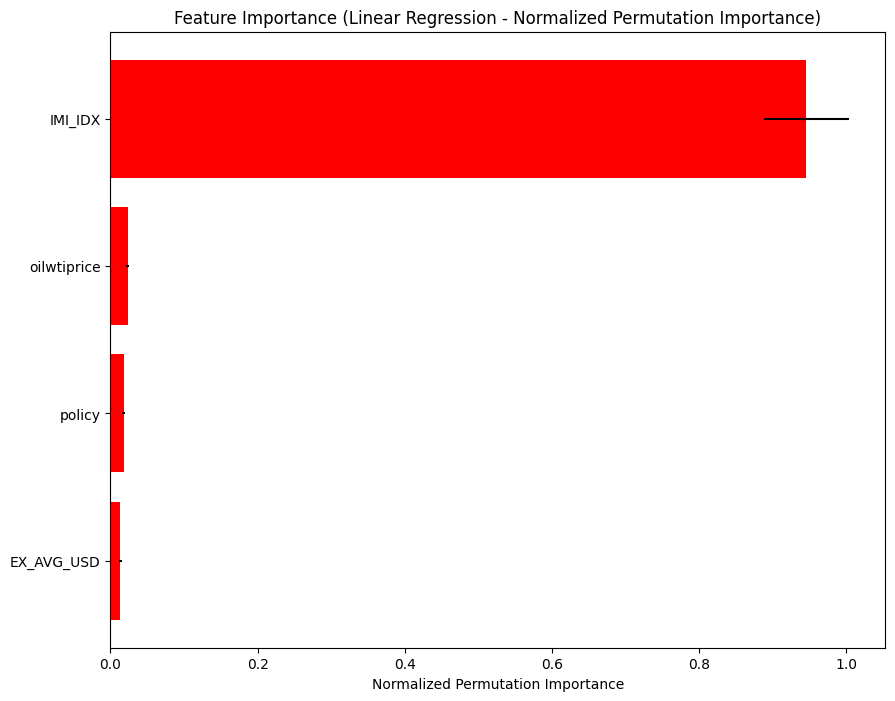

       Feature  Importance   Std_Dev  Normalized_Importance
0   EX_AVG_USD    0.030943  0.004704               0.013068
2       policy    0.042378  0.004626               0.017897
3  oilwtiprice    0.055352  0.004145               0.023376
1      IMI_IDX    2.239190  0.135727               0.945659
{'importances_mean': array([0.03094273, 2.23919026, 0.04237763, 0.05535157]), 'importances_std': array([0.00470372, 0.13572711, 0.0046261 , 0.00414509]), 'importances': array([[0.02517457, 0.02845385, 0.02819466, 0.03016619, 0.02371052,
        0.03218656, 0.03874818, 0.03506256, 0.03738635, 0.0303438 ],
       [2.37537893, 2.05945265, 2.28980944, 2.02295811, 2.04650686,
        2.32126861, 2.25245879, 2.3258589 , 2.41365384, 2.28455649],
       [0.0351598 , 0.03738618, 0.04438255, 0.03960897, 0.04120062,
        0.05059388, 0.04002411, 0.04082886, 0.04752753, 0.04706381],
       [0.05091782, 0.05288126, 0.05654279, 0.0501252 , 0.05915729,
        0.06330276, 0.05447441, 0.05949982, 0.055884

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = X_train.columns

perm_importance = permutation_importance(linear_model_power, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean'],
    'Std_Dev': perm_importance['importances_std'] # Add standard deviation
})

perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
# Use barh with xerr for horizontal error bars
plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], xerr=perm_importance_df['Std_Dev'] / np.abs(perm_importance_df['Importance']).sum() , color='red')
plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Linear Regression - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show() # Add plt.show() to display the plot
print(perm_importance_df)
print(perm_importance )

       Feature  Importance  Normalized_Importance
0   EX_AVG_USD    0.030943               0.013068
2       policy    0.042378               0.017897
3  oilwtiprice    0.055352               0.023376
1      IMI_IDX    2.239190               0.945659
{'importances_mean': array([0.03094273, 2.23919026, 0.04237763, 0.05535157]), 'importances_std': array([0.00470372, 0.13572711, 0.0046261 , 0.00414509]), 'importances': array([[0.02517457, 0.02845385, 0.02819466, 0.03016619, 0.02371052,
        0.03218656, 0.03874818, 0.03506256, 0.03738635, 0.0303438 ],
       [2.37537893, 2.05945265, 2.28980944, 2.02295811, 2.04650686,
        2.32126861, 2.25245879, 2.3258589 , 2.41365384, 2.28455649],
       [0.0351598 , 0.03738618, 0.04438255, 0.03960897, 0.04120062,
        0.05059388, 0.04002411, 0.04082886, 0.04752753, 0.04706381],
       [0.05091782, 0.05288126, 0.05654279, 0.0501252 , 0.05915729,
        0.06330276, 0.05447441, 0.05949982, 0.05588419, 0.05073014]])}


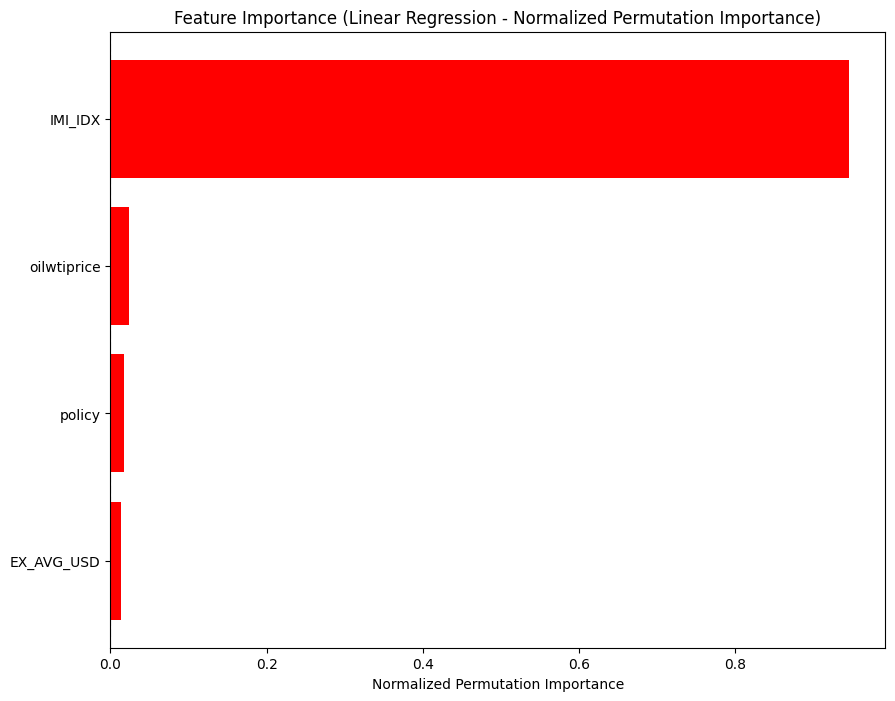

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = X_train.columns

perm_importance = permutation_importance(linear_model_power, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean']
})

perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='red')
plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Linear Regression - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
print(perm_importance_df)
print(perm_importance )

In [ ]:
X_train.columns

Index(['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice'], dtype='object')

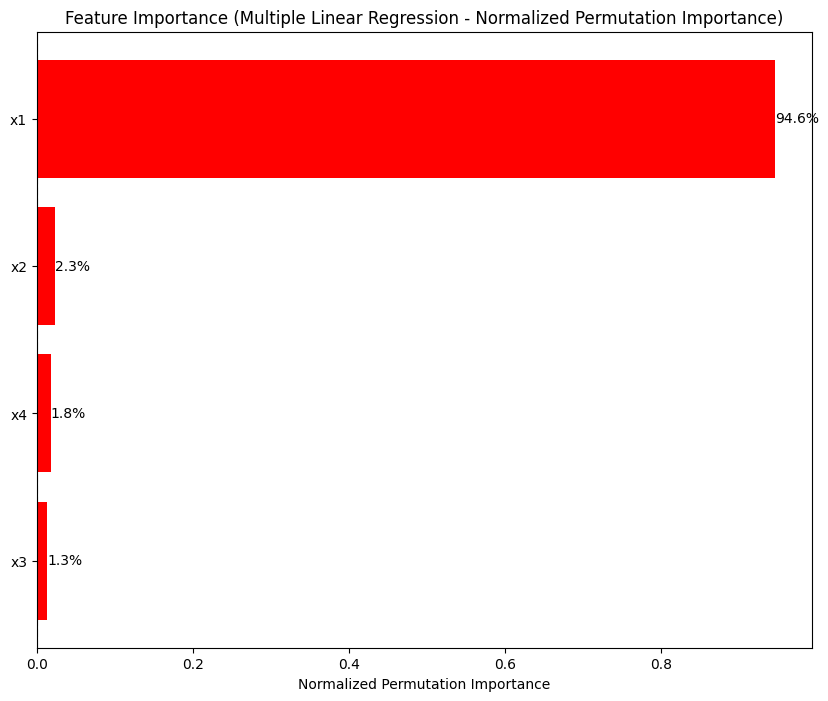

  Feature  Importance  Normalized_Importance
0      x3    0.030943               0.013068
2      x4    0.042378               0.017897
3      x2    0.055352               0.023376
1      x1    2.239190               0.945659
{'importances_mean': array([0.03094273, 2.23919026, 0.04237763, 0.05535157]), 'importances_std': array([0.00470372, 0.13572711, 0.0046261 , 0.00414509]), 'importances': array([[0.02517457, 0.02845385, 0.02819466, 0.03016619, 0.02371052,
        0.03218656, 0.03874818, 0.03506256, 0.03738635, 0.0303438 ],
       [2.37537893, 2.05945265, 2.28980944, 2.02295811, 2.04650686,
        2.32126861, 2.25245879, 2.3258589 , 2.41365384, 2.28455649],
       [0.0351598 , 0.03738618, 0.04438255, 0.03960897, 0.04120062,
        0.05059388, 0.04002411, 0.04082886, 0.04752753, 0.04706381],
       [0.05091782, 0.05288126, 0.05654279, 0.0501252 , 0.05915729,
        0.06330276, 0.05447441, 0.05949982, 0.05588419, 0.05073014]])}


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_train, X_train_log, y_train_log, linear_model_power are defined
feature_names = ['x3','x1','x4','x2']

perm_importance = permutation_importance(linear_model_power, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean']
})

perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10, 8))
bars = plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='red')

# Add percentage labels to the bars
for bar, importance in zip(bars, perm_importance_df['Normalized_Importance']):
    width = bar.get_width()
    # Position the text at the end of the bar (slightly offset)
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
             ha='left' if width >= 0 else 'right',
             va='center')

plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Multiple Linear Regression - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()

print(perm_importance_df)
print(perm_importance)

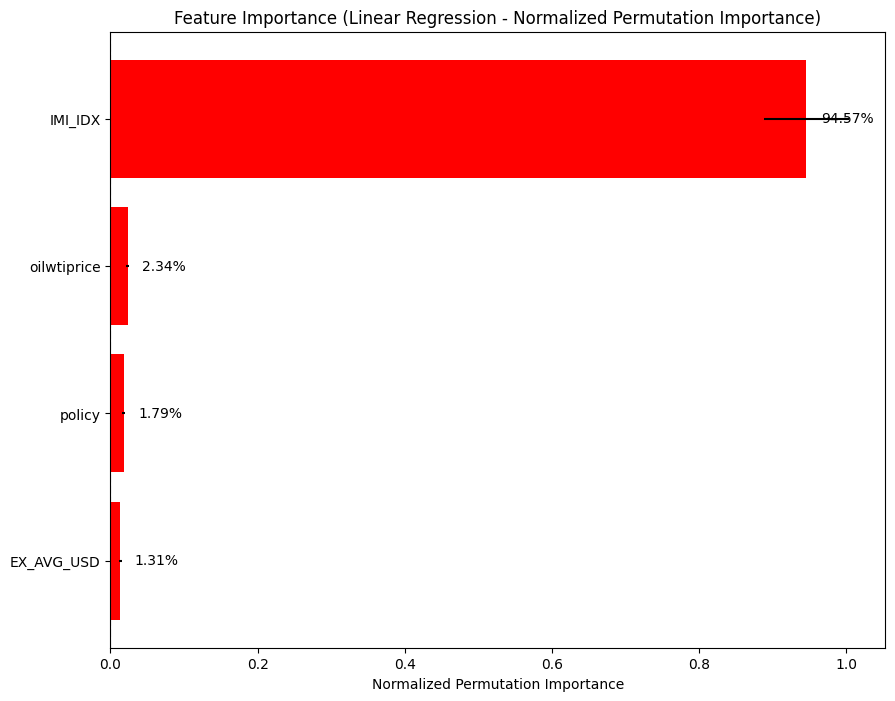


Feature Importance Table:
       Feature  Importance   Std_Dev  Normalized_Importance  \
0   EX_AVG_USD    0.030943  0.004704               0.013068   
2       policy    0.042378  0.004626               0.017897   
3  oilwtiprice    0.055352  0.004145               0.023376   
1      IMI_IDX    2.239190  0.135727               0.945659   

   Importance_Percentage  
0               1.306779  
2               1.789700  
3               2.337618  
1              94.565903  

Percentage Importance Explanation:
Feature 'EX_AVG_USD': Contributes 1.31% to the model's predictive power.
Feature 'policy': Contributes 1.79% to the model's predictive power.
Feature 'oilwtiprice': Contributes 2.34% to the model's predictive power.
Feature 'IMI_IDX': Contributes 94.57% to the model's predictive power.

Raw Permutation Importance Results:
{'importances_mean': array([0.03094273, 2.23919026, 0.04237763, 0.05535157]), 'importances_std': array([0.00470372, 0.13572711, 0.0046261 , 0.00414509]), 'importa

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Assume linear_model_power, X_train_log, y_train_log, and X_train are defined
feature_names = X_train.columns

# Calculate permutation importance
perm_importance = permutation_importance(
    linear_model_power,
    X_train_log,
    y_train_log,
    n_repeats=10,
    random_state=1234,
    scoring='r2'
)

# Create DataFrame with feature importance and standard deviation
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean'],
    'Std_Dev': perm_importance['importances_std']
})

# Calculate normalized importance and percentage
perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()
perm_importance_df['Importance_Percentage'] = perm_importance_df['Normalized_Importance'] * 100

# Sort by Importance (mean) for plotting
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# Plot normalized permutation importance with error bars and percentage labels
plt.figure(figsize=(10, 8))
bars = plt.barh(
    perm_importance_df['Feature'],
    perm_importance_df['Normalized_Importance'],
    xerr=perm_importance_df['Std_Dev'] / np.abs(perm_importance_df['Importance']).sum(),
    color='red'
)
plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Linear Regression - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')

# Add percentage labels to the bars
for i, bar in enumerate(bars):
    width = bar.get_width()  # Get the width of the bar (Normalized_Importance)
    percentage = perm_importance_df['Importance_Percentage'].iloc[i]
    # Place the text at the end of the bar (slightly offset for readability)
    plt.text(
        width + (0.02 if width >= 0 else -0.02),  # Adjust position based on positive/negative importance
        bar.get_y() + bar.get_height() / 2,  # Center vertically
        f'{percentage:.2f}%',  # Format as percentage with 2 decimal places
        ha='left' if width >= 0 else 'right',  # Align text based on bar direction
        va='center',
        fontsize=10
    )

plt.show()

# Print the DataFrame with percentage importance
print("\nFeature Importance Table:")
print(perm_importance_df[['Feature', 'Importance', 'Std_Dev', 'Normalized_Importance', 'Importance_Percentage']])

# Print explanation of percentage importance
print("\nPercentage Importance Explanation:")
for index, row in perm_importance_df.iterrows():
    print(f"Feature '{row['Feature']}': Contributes {row['Importance_Percentage']:.2f}% to the model's predictive power.")

# Print raw permutation importance results for reference
print("\nRaw Permutation Importance Results:")
print(perm_importance)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf_model = RandomForestRegressor(random_state=69, n_estimators=100, min_samples_leaf=4, min_samples_split=2)

rf_model.fit(X_train_log, y_train_log)

y_pred_rf = rf_model.predict(X_test_log)

r2ln = r2_score(y_test_log, y_pred_rf)
mseln = mean_squared_error(y_test_log, y_pred_rf)
maeln = mean_absolute_error(y_test_log, y_pred_rf)
rmseln = np.sqrt(mseln)

print(f'R-squared Score (LN): {r2ln:.3f}')
print(f'Mean Squared Error (LN): {mseln:.3f}')
print(f'Mean Absolute Error (LN): {maeln:.3f}')
print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

R-squared Score (LN): 0.974
Mean Squared Error (LN): 0.000
Mean Absolute Error (LN): 0.011
Root Mean Squared Error (LN): 0.013


In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from sklearn.model_selection import GridSearchCV
# import numpy as np

# # Define the RandomForestRegressor model
# rf_model = RandomForestRegressor(random_state=69)

# # Define the parameter grid for GridSearchCV
# param_grid = {
#     'n_estimators': [50, 100, 200],  # Number of trees
#     'max_depth': [None, 10, 20, 30],  # Maximum depth of trees
#     'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
#     'min_samples_leaf': [1, 2, 4]  # Minimum samples at a leaf node
# }

# # Initialize GridSearchCV
# grid_search = GridSearchCV(
#     estimator=rf_model,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',  # Use negative MSE as the scoring metric
#     cv=5,  # 5-fold cross-validation
#     n_jobs=-1,  # Use all available CPU cores
#     verbose=1
# )

# # Fit GridSearchCV to the training data
# grid_search.fit(X_train_log, y_train_log)

# # Get the best model from GridSearchCV
# best_rf_model = grid_search.best_estimator_

# # Predict on the test set using the best model
# y_pred_rf = best_rf_model.predict(X_test_log)

# # Calculate evaluation metrics
# r2ln = r2_score(y_test_log, y_pred_rf)
# mseln = mean_squared_error(y_test_log, y_pred_rf)
# maeln = mean_absolute_error(y_test_log, y_pred_rf)
# rmseln = np.sqrt(mseln)

# # Print the best parameters and evaluation metrics
# print("Best Parameters from GridSearchCV:")
# print(grid_search.best_params_)
# print(f'R-squared Score (LN): {r2ln:.3f}')
# print(f'Mean Squared Error (LN): {mseln:.3f}')
# print(f'Mean Absolute Error (LN): {maeln:.3f}')
# print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

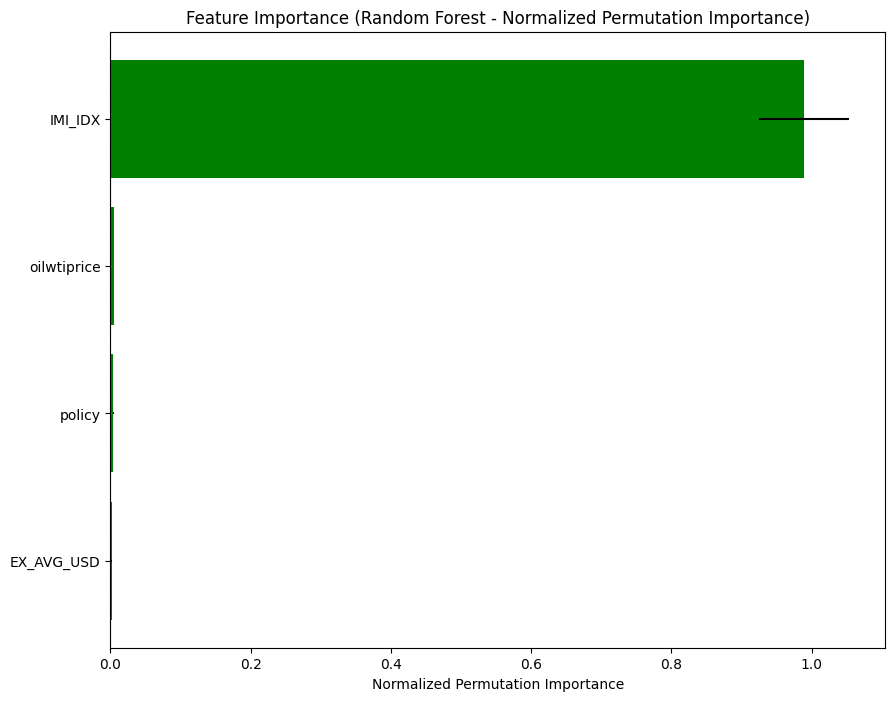

       Feature  Importance   Std_Dev  Normalized_Importance
0   EX_AVG_USD    0.003072  0.000406               0.001580
2       policy    0.008254  0.001375               0.004245
3  oilwtiprice    0.009846  0.001017               0.005064
1      IMI_IDX    1.923127  0.123501               0.989111
{'importances_mean': array([0.00307167, 1.92312715, 0.00825376, 0.00984606]), 'importances_std': array([0.00040581, 0.12350148, 0.001375  , 0.00101744]), 'importances': array([[0.00260609, 0.00296769, 0.0030315 , 0.00273698, 0.00292641,
        0.00347258, 0.00276324, 0.00278999, 0.00345468, 0.00396757],
       [2.02299363, 1.80425622, 2.06746603, 1.72364336, 1.77408401,
        2.05195479, 1.90261711, 1.84350511, 2.06105587, 1.97969531],
       [0.0072709 , 0.00665272, 0.00681126, 0.00941946, 0.00971545,
        0.00853416, 0.00705057, 0.00833848, 0.00767449, 0.0110701 ],
       [0.00977904, 0.0114177 , 0.00878522, 0.00985666, 0.01110693,
        0.0085225 , 0.00870245, 0.00912245, 0.010088

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming rf_model (RandomForestRegressor) is already trained
# Assuming X_train_log and y_train_log are the training data used for rf_model

feature_names = X_train_log.columns # Use columns from X_train_log

# Calculate permutation importance for the Random Forest model
perm_importance = permutation_importance(rf_model, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean'],
    'Std_Dev': perm_importance['importances_std'] # Add standard deviation
})

# Normalize importance values
perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart with error bars
plt.figure(figsize=(10, 8))
# Use barh with xerr for horizontal error bars
plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], xerr=perm_importance_df['Std_Dev'] / np.abs(perm_importance_df['Importance']).sum() , color='green')
plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Random Forest - Normalized Permutation Importance)') # Update title
plt.axvline(x=0, color='grey', linestyle='--')
plt.show() # Add plt.show() to display the plot

print(perm_importance_df)
print(perm_importance )

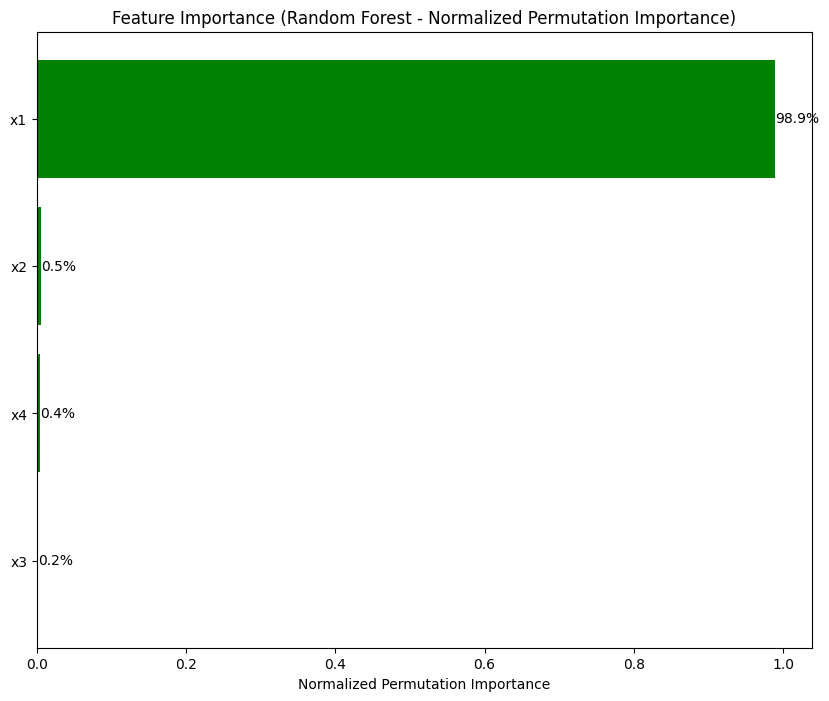

  Feature  Importance   Std_Dev  Normalized_Importance
0      x3    0.003072  0.000406               0.001580
2      x4    0.008254  0.001375               0.004245
3      x2    0.009846  0.001017               0.005064
1      x1    1.923127  0.123501               0.989111
{'importances_mean': array([0.00307167, 1.92312715, 0.00825376, 0.00984606]), 'importances_std': array([0.00040581, 0.12350148, 0.001375  , 0.00101744]), 'importances': array([[0.00260609, 0.00296769, 0.0030315 , 0.00273698, 0.00292641,
        0.00347258, 0.00276324, 0.00278999, 0.00345468, 0.00396757],
       [2.02299363, 1.80425622, 2.06746603, 1.72364336, 1.77408401,
        2.05195479, 1.90261711, 1.84350511, 2.06105587, 1.97969531],
       [0.0072709 , 0.00665272, 0.00681126, 0.00941946, 0.00971545,
        0.00853416, 0.00705057, 0.00833848, 0.00767449, 0.0110701 ],
       [0.00977904, 0.0114177 , 0.00878522, 0.00985666, 0.01110693,
        0.0085225 , 0.00870245, 0.00912245, 0.01008874, 0.01107889]])}


In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming rf_model (RandomForestRegressor) is already trained
# Assuming X_train_log and y_train_log are the training data used for rf_model

feature_names = ['x3','x1','x4','x2']
 # Use columns from X_train_log

# Calculate permutation importance for the Random Forest model
perm_importance = permutation_importance(rf_model, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean'],
    'Std_Dev': perm_importance['importances_std']  # Add standard deviation
})

# Normalize importance values
perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart without error bars
plt.figure(figsize=(10, 8))
bars = plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='green')

# Add percentage labels to the bars
for bar, importance in zip(bars, perm_importance_df['Normalized_Importance']):
    width = bar.get_width()
    # Position the text at the end of the bar (slightly offset)
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
             ha='left' if width >= 0 else 'right',
             va='center')

plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Random Forest - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()

print(perm_importance_df)
print(perm_importance)

In [ ]:
print(X_train.head())
print(X_train_log.head())

   EX_AVG_USD   IMI_IDX    policy  oilwtiprice
0    0.795583  0.769056  0.941176     0.685299
1    0.971951  0.828214 -0.235294     0.773354
2    0.151006 -0.282139  0.000000    -0.390123
3    0.549287 -0.359499  0.000000    -0.516845
4    0.627486 -0.409556  0.000000    -0.460567
   EX_AVG_USD   IMI_IDX    policy  oilwtiprice
0    0.795583  0.769056  0.941176     0.685299
1    0.971951  0.828214 -0.235294     0.773354
2    0.151006 -0.282139  0.000000    -0.390123
3    0.549287 -0.359499  0.000000    -0.516845
4    0.627486 -0.409556  0.000000    -0.460567


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Initialize and train the SVR model
# Using default parameters for now, can be tuned later
svr_model = SVR(kernel='linear',C = 500,epsilon = 0.1, degree=2)

# Fit the model on the training data
# Using X_train_log and y_train_log which have been processed (imputed, scaled, transformed)
svr_model.fit(X_train_log, y_train_log)

# Make predictions on the test data
y_pred_svr = svr_model.predict(X_test_log)

# Evaluate the model's performance
r2_svr = r2_score(y_test_log, y_pred_svr)
mse_svr = mean_squared_error(y_test_log, y_pred_svr)
mae_svr = mean_absolute_error(y_test_log, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(f'R-squared Score (SVR): {r2_svr:.3f}')
print(f'Mean Squared Error (SVR): {mse_svr:.3f}')
print(f'Mean Absolute Error (SVR): {mae_svr:.3f}')
print(f'Root Mean Squared Error (SVR): {rmse_svr:.3f}')

R-squared Score (SVR): 0.020
Mean Squared Error (SVR): 0.006
Mean Absolute Error (SVR): 0.076
Root Mean Squared Error (SVR): 0.077


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_predict, LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Initialize the SVR model
# ใช้พารามิเตอร์พื้นฐานก่อน (สามารถปรับจาก GridSearchCV ได้)
# svr_model = SVR(kernel ='linear', C=0.01, degree=2, epsilon=0.001, gamma="scale")  # หรือใช้ best_params จาก GridSearchCV

# Initialize Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Perform cross-validation prediction using LOO
y_pred_loo = cross_val_predict(
    estimator=svr_model,
    X=X_train_log,  # หรือ X_train ถ้าไม่ใช้ log transform
    y=y_train_log,  # หรือ y_train
    cv=loo,
    n_jobs=-1  # ใช้ทุก CPU core เพื่อเร่งความเร็ว
)

# Calculate evaluation metrics on the LOO predictions
r2_loo = r2_score(y_train_log, y_pred_loo)
mse_loo = mean_squared_error(y_train_log, y_pred_loo)
mae_loo = mean_absolute_error(y_train_log, y_pred_loo)
rmse_loo = np.sqrt(mse_loo)

# Print the results
print(f'R-squared Score (SVR - LOO): {r2_loo:.3f}')
print(f'Mean Squared Error (SVR - LOO): {mse_loo:.3f}')
print(f'Mean Absolute Error (SVR - LOO): {mae_loo:.3f}')
print(f'Root Mean Squared Error (SVR - LOO): {rmse_loo:.3f}')

R-squared Score (SVR - LOO): -0.020
Mean Squared Error (SVR - LOO): 0.005
Mean Absolute Error (SVR - LOO): 0.067
Root Mean Squared Error (SVR - LOO): 0.070


In [ ]:
# from sklearn.svm import SVR
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from sklearn.model_selection import GridSearchCV
# import numpy as np

# # Define the SVR model
# svr_model = SVR()

# # Define an extensive parameter grid for GridSearchCV
# param_grid = {
#     'kernel': ['linear', 'rbf', 'poly'],  # Kernel types
#     'C': [0.01, 0.1, 1, 10, 50, 100, 500],  # Extensive range for regularization
#     'epsilon': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],  # Extensive range for epsilon
#     'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0, 10.0],  # Extensive range for rbf/poly kernels
#     'degree': [2, 3, 4]  # Degrees for poly kernel
# }

# # Initialize GridSearchCV
# grid_search = GridSearchCV(
#     estimator=svr_model,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',  # Optimize for lowest MSE
#     cv=5,  # 5-fold cross-validation
#     n_jobs=-1,  # Use all available CPU cores
#     verbose=2  # More detailed output for tracking progress
# )

# # Fit GridSearchCV to the training data
# grid_search.fit(X_train_log, y_train_log)

# # Get the best model from GridSearchCV
# best_svr_model = grid_search.best_estimator_

# # Predict on the test set using the best model
# y_pred_svr = best_svr_model.predict(X_test_log)

# # Calculate evaluation metrics
# r2_svr = r2_score(y_test_log, y_pred_svr)
# mse_svr = mean_squared_error(y_test_log, y_pred_svr)
# mae_svr = mean_absolute_error(y_test_log, y_pred_svr)
# rmse_svr = np.sqrt(mse_svr)

# # Print the best parameters and evaluation metrics
# print("Best Parameters from GridSearchCV:")
# print(grid_search.best_params_)
# print(f'R-squared Score (SVR): {r2_svr:.3f}')
# print(f'Mean Squared Error (SVR): {mse_svr:.3f}')
# print(f'Mean Absolute Error (SVR): {mae_svr:.3f}')
# print(f'Root Mean Squared Error (SVR): {rmse_svr:.3f}')

# # Optional: Print cross-validation results for top 5 parameter sets
# import pandas as pd
# results = pd.DataFrame(grid_search.cv_results_)
# top_results = results[['param_kernel', 'param_C', 'param_epsilon', 'param_gamma', 'param_degree', 'mean_test_score', 'std_test_score']].head()
# print("\nTop 5 Parameter Sets from GridSearchCV:")
# print(top_results)

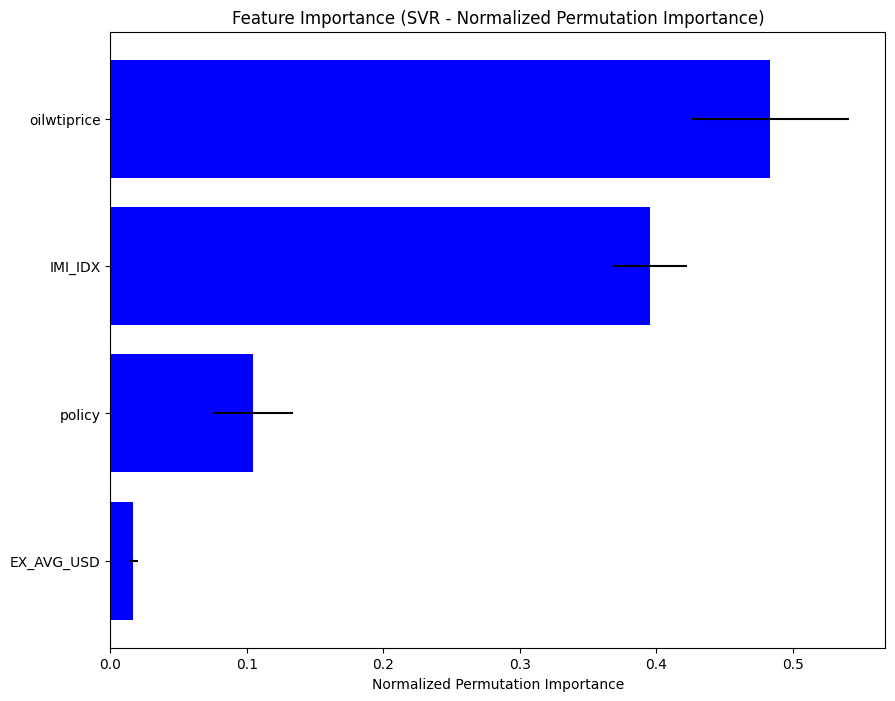

       Feature  Importance   Std_Dev  Normalized_Importance
0   EX_AVG_USD    0.001143  0.000241               0.016757
2       policy    0.007109  0.001995               0.104231
1      IMI_IDX    0.026960  0.001853               0.395309
3  oilwtiprice    0.032989  0.003910               0.483703
{'importances_mean': array([0.00114285, 0.02696021, 0.00710861, 0.03298875]), 'importances_std': array([0.00024105, 0.00185331, 0.00199482, 0.0039101 ]), 'importances': array([[0.00105902, 0.0015668 , 0.00112346, 0.00153619, 0.00121957,
        0.00116263, 0.0007674 , 0.00093821, 0.00113599, 0.00091918],
       [0.02814332, 0.0250554 , 0.02846209, 0.02487041, 0.02418803,
        0.02844548, 0.02729258, 0.02539206, 0.03007901, 0.02767374],
       [0.00890645, 0.00705842, 0.00587043, 0.00912495, 0.00740468,
        0.00677326, 0.00188494, 0.00865974, 0.00727526, 0.00812798],
       [0.03874732, 0.02658442, 0.03583635, 0.03224641, 0.02967346,
        0.03632672, 0.03461237, 0.0277822 , 0.036864

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming svr_model is already trained
# Assuming X_train_log and y_train_log are the training data used for svr_model

feature_names = X_train_log.columns # Use columns from X_train_log

# Refit the SVR model before calculating permutation importance
# Using the same parameters as the last successful SVR fit
svr_model.fit(X_train_log, y_train_log)


# Calculate permutation importance for the SVR model
perm_importance_svr = permutation_importance(svr_model, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df_svr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance_svr['importances_mean'],
    'Std_Dev': perm_importance_svr['importances_std'] # Add standard deviation
})

# Normalize importance values
perm_importance_df_svr['Normalized_Importance'] = perm_importance_df_svr['Importance'] / np.abs(perm_importance_df_svr['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df_svr = perm_importance_df_svr.sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart with error bars
plt.figure(figsize=(10, 8))
# Use barh with xerr for horizontal error bars
plt.barh(perm_importance_df_svr['Feature'], perm_importance_df_svr['Normalized_Importance'], xerr=perm_importance_df_svr['Std_Dev'] / np.abs(perm_importance_df_svr['Importance']).sum() , color='blue') # Changed color to blue
plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (SVR - Normalized Permutation Importance)') # Updated title
plt.axvline(x=0, color='grey', linestyle='--')
plt.show() # Add plt.show() to display the plot

print(perm_importance_df_svr)
print(perm_importance_svr )

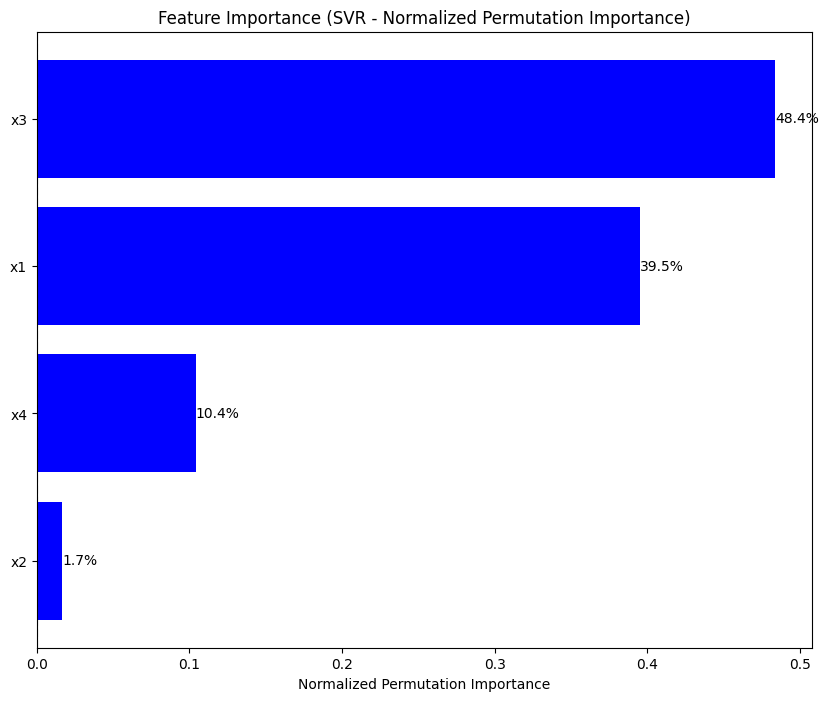

  Feature  Importance   Std_Dev  Normalized_Importance
0      x2    0.001143  0.000241               0.016757
2      x4    0.007109  0.001995               0.104231
1      x1    0.026960  0.001853               0.395309
3      x3    0.032989  0.003910               0.483703
{'importances_mean': array([0.00114285, 0.02696021, 0.00710861, 0.03298875]), 'importances_std': array([0.00024105, 0.00185331, 0.00199482, 0.0039101 ]), 'importances': array([[0.00105902, 0.0015668 , 0.00112346, 0.00153619, 0.00121957,
        0.00116263, 0.0007674 , 0.00093821, 0.00113599, 0.00091918],
       [0.02814332, 0.0250554 , 0.02846209, 0.02487041, 0.02418803,
        0.02844548, 0.02729258, 0.02539206, 0.03007901, 0.02767374],
       [0.00890645, 0.00705842, 0.00587043, 0.00912495, 0.00740468,
        0.00677326, 0.00188494, 0.00865974, 0.00727526, 0.00812798],
       [0.03874732, 0.02658442, 0.03583635, 0.03224641, 0.02967346,
        0.03632672, 0.03461237, 0.0277822 , 0.03686478, 0.03121345]])}


In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming svr_model is already trained
# Assuming X_train_log and y_train_log are the training data used for svr_model

feature_names = ['x2','x1','x4','x3']  # Use columns from X_train_log

# Refit the SVR model before calculating permutation importance
# Using the same parameters as the last successful SVR fit
svr_model.fit(X_train_log, y_train_log)

# Calculate permutation importance for the SVR model
perm_importance_svr = permutation_importance(svr_model, X_train_log, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df_svr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance_svr['importances_mean'],
    'Std_Dev': perm_importance_svr['importances_std']  # Add standard deviation
})

# Normalize importance values
perm_importance_df_svr['Normalized_Importance'] = perm_importance_df_svr['Importance'] / np.abs(perm_importance_df_svr['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df_svr = perm_importance_df_svr.sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart without error bars
plt.figure(figsize=(10, 8))
bars = plt.barh(perm_importance_df_svr['Feature'], perm_importance_df_svr['Normalized_Importance'], color='blue')

# Add percentage labels to the bars
for bar, importance in zip(bars, perm_importance_df_svr['Normalized_Importance']):
    width = bar.get_width()
    # Position the text at the end of the bar (slightly offset)
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
             ha='left' if width >= 0 else 'right',
             va='center')

plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (SVR - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()

print(perm_importance_df_svr)
print(perm_importance_svr)